<a href="https://colab.research.google.com/github/vaibhavjiyer87/engine-nvh-deep-learning/blob/main/notebooks/12_project_closeout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Step 111  Audit final artifacts
* Step 112  Build master experiment table
* Step 113  Create final comparison figures
* Step 114  Write engineering interpretation
* Step 115  Upgrade README into portfolio case study
* Step 116  Document reproducibility + architecture
* Step 117  Clean and validate repository
* Step 118  Create portfolio + working-style summaries
* Step 119  Final GitHub synchronization
* Step 120  PROJECT COMPLETE

In [ ]:
# Step 111 — Audit the complete project

# Step 111.1 — Create Notebook 12
# Create: notebooks/12_project_closeout.ipynb
# Save it immediately to GitHub, then run your normal Startup Cells 1–5.


In [1]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 1 — Mount Google Drive

# ============================================================
# CELL 1 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# Persistent project location in Google Drive
PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/01_EngineOperatingState"
)

if not PROJECT_DRIVE.exists():
    raise FileNotFoundError(
        f"Project folder was not found:\n{PROJECT_DRIVE}"
    )

print("Google Drive mounted successfully.")
print(f"Project Drive: {PROJECT_DRIVE}")

Mounted at /content/drive
Google Drive mounted successfully.
Project Drive: /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState


In [2]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 2 — Authenticate GitHub + determine Git author identity
# This assumes your GitHub token is stored in Colab Secrets under:
# GITHUB_TOKEN

# ============================================================
# CELL 2 — AUTHENTICATE GITHUB
# ============================================================

from google.colab import userdata

import os
import shutil
import subprocess


# ------------------------------------------------------------
# Repository settings
# ------------------------------------------------------------

REPOSITORY_NAME = "engine-nvh-deep-learning"


# ------------------------------------------------------------
# Load GitHub token securely from Colab Secrets
# ------------------------------------------------------------

github_token = userdata.get("GITHUB_TOKEN")

if not github_token:
    raise ValueError(
        "GITHUB_TOKEN was not found in Colab Secrets.\n"
        "Add the token and enable Notebook access."
    )

# GitHub CLI recognizes GH_TOKEN automatically.
os.environ["GH_TOKEN"] = github_token
os.environ["GH_HOST"] = "github.com"


# ------------------------------------------------------------
# Install GitHub CLI if necessary
# ------------------------------------------------------------

if shutil.which("gh") is None:

    print("Installing GitHub CLI...")

    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "gh",
        ],
        check=True,
    )


# ------------------------------------------------------------
# Verify authentication
# ------------------------------------------------------------

auth_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".login",
    ],
    capture_output=True,
    text=True,
)

if auth_result.returncode != 0:

    print(auth_result.stderr)

    raise RuntimeError(
        "GitHub authentication failed."
    )


GITHUB_USERNAME = auth_result.stdout.strip()

# ------------------------------------------------------------
# Configure Git commit identity
# ------------------------------------------------------------

user_id_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".id",
    ],
    capture_output=True,
    text=True,
    check=True,
)

GITHUB_USER_ID = (
    user_id_result.stdout.strip()
)

GIT_NAME = GITHUB_USERNAME

GIT_EMAIL = (
    f"{GITHUB_USER_ID}+"
    f"{GITHUB_USERNAME}@users.noreply.github.com"
)

print("Git identity prepared.")
print(f"Name:  {GIT_NAME}")
print(f"Email: {GIT_EMAIL}")

# ------------------------------------------------------------
# Configure Git to use GitHub CLI authentication
# ------------------------------------------------------------

subprocess.run(
    [
        "gh",
        "auth",
        "setup-git",
        "--hostname",
        "github.com",
        "--force",
    ],
    check=True,
)


print("GitHub authentication successful.")
print(f"GitHub user: {GITHUB_USERNAME}")
print(f"Repository:  {REPOSITORY_NAME}")

Git identity prepared.
Name:  vaibhavjiyer87
Email: 312107027+vaibhavjiyer87@users.noreply.github.com
GitHub authentication successful.
GitHub user: vaibhavjiyer87
Repository:  engine-nvh-deep-learning


In [3]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 3 — Clone repository if .git is missing / Update repository
# This cell deals with the temporary nature of /content.

# ============================================================
# CELL 3 — RESTORE LOCAL GITHUB REPOSITORY
# ============================================================

from pathlib import Path
import shutil
import subprocess


TEMP_REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

REPOSITORY_IDENTIFIER = (
    f"{GITHUB_USERNAME}/"
    f"{REPOSITORY_NAME}"
)


# ------------------------------------------------------------
# Case 1:
# Valid Git repository already exists
# ------------------------------------------------------------

if (
    TEMP_REPO_DIR.exists()
    and
    (TEMP_REPO_DIR / ".git").exists()
):

    print(
        "Git repository already exists "
        "in this Colab runtime."
    )

    # Pull updates only when the working tree is clean.
    status_result = subprocess.run(
        [
            "git",
            "-C",
            str(TEMP_REPO_DIR),
            "status",
            "--porcelain",
        ],
        capture_output=True,
        text=True,
        check=True,
    )

    if status_result.stdout.strip():

        print(
            "Local changes detected."
        )

        print(
            "Automatic git pull skipped "
            "to avoid overwriting local work."
        )

    else:

        print(
            "Working tree is clean. "
            "Updating from GitHub..."
        )

        pull_result = subprocess.run(
            [
                "git",
                "-C",
                str(TEMP_REPO_DIR),
                "pull",
                "--ff-only",
            ],
            capture_output=True,
            text=True,
        )

        print(pull_result.stdout)

        if pull_result.returncode != 0:
            print(pull_result.stderr)


# ------------------------------------------------------------
# Case 2:
# Folder exists, but it is NOT a Git repository
# ------------------------------------------------------------

elif TEMP_REPO_DIR.exists():

    raise RuntimeError(
        f"The folder exists but is not a Git repository:\n"
        f"{TEMP_REPO_DIR}\n\n"
        "Do not run git init. Inspect or back up the folder "
        "before removing it and rerunning this cell."
    )


# ------------------------------------------------------------
# Case 3:
# Fresh runtime — clone repository
# ------------------------------------------------------------

else:

    print(
        "Repository not present in this runtime."
    )

    print(
        f"Cloning {REPOSITORY_IDENTIFIER}..."
    )

    clone_result = subprocess.run(
        [
            "gh",
            "repo",
            "clone",
            REPOSITORY_IDENTIFIER,
            str(TEMP_REPO_DIR),
        ],
        capture_output=True,
        text=True,
    )

    print(clone_result.stdout)

    if clone_result.returncode != 0:

        print(clone_result.stderr)

        raise RuntimeError(
            "Repository clone failed."
        )


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

if not (
    TEMP_REPO_DIR
    / ".git"
).exists():

    raise RuntimeError(
        "Repository restoration failed."
    )


print("Local Git repository is ready.")
print(f"Location: {TEMP_REPO_DIR}")

Repository not present in this runtime.
Cloning vaibhavjiyer87/engine-nvh-deep-learning...

Local Git repository is ready.
Location: /content/engine-nvh-deep-learning


In [4]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 4 — Define REPO_DIR and all standard paths + restore requirements

# ============================================================
# CELL 4 — DEFINE PROJECT PATHS
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# GitHub working repository
# ------------------------------------------------------------

REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

if not (
    REPO_DIR
    / ".git"
).exists():

    raise FileNotFoundError(
        f"Valid Git repository not found at:\n"
        f"{REPO_DIR}\n\n"
        "Run Cell 3 first."
    )


# ------------------------------------------------------------
# Persistent raw dataset
# ------------------------------------------------------------

RAW_ROOT = (
    PROJECT_DRIVE
    / "data"
    / "raw"
    / "procedural_engine_sounds"
)

DATASET_ROOT = (
    RAW_ROOT
    / "dataset"
)

AUDIO_DIR = (
    DATASET_ROOT
    / "audio"
    / "A_full_set"
)


# ------------------------------------------------------------
# Persistent Google Drive manifests
# ------------------------------------------------------------

DRIVE_MANIFEST_DIR = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
)


# ------------------------------------------------------------
# GitHub configuration
# ------------------------------------------------------------

CONFIG_DIR = (
    REPO_DIR
    / "configs"
)

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

SPLIT_DIR = (
    REPO_DIR
    / "data"
    / "splits"
)


# ------------------------------------------------------------
# GitHub result directories
# ------------------------------------------------------------

RESULTS_DIR = (
    REPO_DIR
    / "results"
)

FIGURE_DIR = (
    RESULTS_DIR
    / "figures"
)

TABLE_DIR = (
    RESULTS_DIR
    / "tables"
)

DATA_AUDIT_FIGURE_DIR = (
    FIGURE_DIR
    / "data_audit"
)

DESIGN_FIGURE_DIR = (
    FIGURE_DIR
    / "preprocessing_design"
)

SPLIT_FIGURE_DIR = (
    FIGURE_DIR
    / "split_design"
)


# ------------------------------------------------------------
# Persistent Drive output directories
# ------------------------------------------------------------

DRIVE_OUTPUT_DIR = (
    PROJECT_DRIVE
    / "outputs"
)

DRIVE_DESIGN_TABLE_DIR = (
    DRIVE_OUTPUT_DIR
    / "tables"
    / "preprocessing_design"
)


# ------------------------------------------------------------
# Create output folders if missing
# ------------------------------------------------------------

directories_to_create = [
    CONFIG_DIR,
    REPORT_DIR,
    SPLIT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    DATA_AUDIT_FIGURE_DIR,
    DESIGN_FIGURE_DIR,
    SPLIT_FIGURE_DIR,
    DRIVE_DESIGN_TABLE_DIR,
]

for directory in directories_to_create:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("Project paths restored.")
print()
print(f"REPO_DIR:     {REPO_DIR}")
print(f"PROJECT_DRIVE:{PROJECT_DRIVE}")
print(f"RAW_ROOT:     {RAW_ROOT}")
print(f"AUDIO_DIR:    {AUDIO_DIR}")

# ------------------------------------------------------------
# Apply Git commit identity to cloned repository
# ------------------------------------------------------------

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.name",
        GIT_NAME,
    ],
    check=True,
)

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.email",
        GIT_EMAIL,
    ],
    check=True,
)

print("Git commit identity applied to repository.")

# ------------------------------------------------------------
# Restore project Python dependencies
# ------------------------------------------------------------

import subprocess

REQUIREMENTS_PATH = (
    REPO_DIR
    / "requirements.txt"
)

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"requirements.txt not found:\n"
        f"{REQUIREMENTS_PATH}"
    )

install_result = subprocess.run(
    [
        "python",
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    capture_output=True,
    text=True,
)

if install_result.returncode != 0:

    print(install_result.stdout)
    print(install_result.stderr)

    raise RuntimeError(
        "Project dependency installation failed."
    )

print(
    "Project Python dependencies restored."
)

Project paths restored.

REPO_DIR:     /content/engine-nvh-deep-learning
PROJECT_DRIVE:/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState
RAW_ROOT:     /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds
AUDIO_DIR:    /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set
Git commit identity applied to repository.
Project Python dependencies restored.


In [5]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 5 — Load persistent analysis data
# This cell restores the major tables you've created so far.
# This is conditional, as some files may not exist yet depending on
# where you are in the project.

# ============================================================
# CELL 5 — LOAD PERSISTENT ANALYSIS DATA
# ============================================================

# ============================================================
# STANDARD PROJECT IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import yaml

from tqdm.auto import tqdm

print(
    "Standard project libraries imported."
)


# ------------------------------------------------------------
# 1. Raw-file manifest — REQUIRED
# ------------------------------------------------------------

RAW_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "raw_file_manifest_v001.csv"
)

if not RAW_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Required raw manifest not found:\n"
        f"{RAW_MANIFEST_PATH}"
    )


raw_manifest = pd.read_csv(
    RAW_MANIFEST_PATH
)

print(
    f"LOADED raw_manifest: "
    f"{raw_manifest.shape}"
)


# ------------------------------------------------------------
# 2. PREP-001 detailed target analysis — OPTIONAL
# ------------------------------------------------------------

PREP001_TARGET_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "prep001_target_analysis_v001.csv.gz"
)

if PREP001_TARGET_PATH.exists():

    prep001_targets = pd.read_csv(
        PREP001_TARGET_PATH
    )

    print(
        f"LOADED prep001_targets: "
        f"{prep001_targets.shape}"
    )

else:

    prep001_targets = None

    print(
        "NOT FOUND: prep001 target analysis "
        "(this is okay if it has not been generated yet)."
    )


# ------------------------------------------------------------
# 3. Window candidate metrics — OPTIONAL
# ------------------------------------------------------------

WINDOW_CANDIDATE_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "window_candidate_metrics_v001.csv.gz"
)

if WINDOW_CANDIDATE_PATH.exists():

    window_candidates = pd.read_csv(
        WINDOW_CANDIDATE_PATH
    )

    print(
        f"LOADED window_candidates: "
        f"{window_candidates.shape}"
    )

else:

    window_candidates = None

    print(
        "NOT FOUND: window candidate metrics."
    )


# ------------------------------------------------------------
# 4. Frozen SPLIT-001 file assignment — OPTIONAL
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if FILE_SPLIT_PATH.exists():

    file_split = pd.read_csv(
        FILE_SPLIT_PATH
    )

    print(
        f"LOADED file_split: "
        f"{file_split.shape}"
    )

else:

    file_split = None

    print(
        "NOT FOUND: SPLIT-001 file assignment."
    )


# ============================================================
# LOAD REQUIRED FROZEN PROJECT SPECIFICATIONS
# ============================================================

import yaml


# ------------------------------------------------------------
# PREP-001 — REQUIRED
# ------------------------------------------------------------

PREPROCESSING_CONFIG_PATH = (
    CONFIG_DIR
    / "preprocessing_v001.yaml"
)

if not PREPROCESSING_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required PREP-001 configuration is missing:\n"
        f"{PREPROCESSING_CONFIG_PATH}"
    )


try:

    with open(
        PREPROCESSING_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        preprocessing_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "PREP-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
    != "PREP-001"
):

    raise RuntimeError(
        "Unexpected preprocessing version."
    )


print(
    "LOADED preprocessing_config: PREP-001"
)


# ------------------------------------------------------------
# SPLIT-001 — REQUIRED
# ------------------------------------------------------------

SPLIT_CONFIG_PATH = (
    CONFIG_DIR
    / "split_v001.yaml"
)

if not SPLIT_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 configuration is missing:\n"
        f"{SPLIT_CONFIG_PATH}"
    )


try:

    with open(
        SPLIT_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        split_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "SPLIT-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    split_config[
        "specification"
    ]["split_version"]
    != "SPLIT-001"
):

    raise RuntimeError(
        "Unexpected split version."
    )


print(
    "LOADED split_config: SPLIT-001"
)


# ------------------------------------------------------------
# FILE SPLIT — REQUIRED
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if not FILE_SPLIT_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 assignment file is missing:\n"
        f"{FILE_SPLIT_PATH}"
    )


file_split = pd.read_csv(
    FILE_SPLIT_PATH
)

print(
    f"LOADED file_split: "
    f"{file_split.shape}"
)


# ============================================================
# DERIVE FROZEN RUNTIME CONSTANTS
# ============================================================

# ------------------------------------------------------------
# PREP-001 identity
# ------------------------------------------------------------

PREPROCESSING_VERSION = (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
)

DATASET_SUBSET = (
    preprocessing_config[
        "specification"
    ]["dataset_subset"]
)


# ------------------------------------------------------------
# Windowing
# ------------------------------------------------------------

WINDOW_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["window_duration_s"]
)

OVERLAP_FRACTION = float(
    preprocessing_config[
        "windowing"
    ]["overlap_fraction"]
)

HOP_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["hop_duration_s"]
)


# ------------------------------------------------------------
# Source-data definition
# ------------------------------------------------------------

SOURCE_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "source_data"
    ]["source_sample_rate_hz"]
)

EXPECTED_CHANNELS = int(
    preprocessing_config[
        "source_data"
    ]["expected_channels"]
)

RPM_SCALE_FACTOR = float(
    preprocessing_config[
        "source_data"
    ]["rpm_scale_factor"]
)

TORQUE_SCALE_FACTOR_NM = float(
    preprocessing_config[
        "source_data"
    ]["torque_scale_factor_nm"]
)


# ------------------------------------------------------------
# YAML channel numbers are human-readable 1-based numbers.
# NumPy arrays use 0-based indexing.
# ------------------------------------------------------------

RPM_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["rpm"]
    )
    - 1
)

TORQUE_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["torque"]
    )
    - 1
)


# ------------------------------------------------------------
# Audio processing
# ------------------------------------------------------------

TARGET_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "audio_processing"
    ]["target_sample_rate_hz"]
)

AUDIO_CHANNEL_STRATEGY = (
    preprocessing_config[
        "audio_processing"
    ]["channel_strategy"]
)


# ------------------------------------------------------------
# Steady-state criterion
# ------------------------------------------------------------

ABSOLUTE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_absolute_range_rpm"
    ]
)

RELATIVE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_relative_range_fraction"
    ]
)


# ------------------------------------------------------------
# SPLIT-001 identity
# ------------------------------------------------------------

SPLIT_VERSION = (
    split_config[
        "specification"
    ]["split_version"]
)


print("Frozen runtime constants restored.")
print()
print(f"Preprocessing:       {PREPROCESSING_VERSION}")
print(f"Split:               {SPLIT_VERSION}")
print(f"Dataset subset:      {DATASET_SUBSET}")
print(f"Window duration:     {WINDOW_DURATION_S} s")
print(f"Overlap:             {100 * OVERLAP_FRACTION:.0f}%")
print(f"Source sample rate:  {SOURCE_SAMPLE_RATE_HZ} Hz")
print(f"Target sample rate:  {TARGET_SAMPLE_RATE_HZ} Hz")
print(f"Expected channels:   {EXPECTED_CHANNELS}")
print(f"RPM channel index:   {RPM_CHANNEL_INDEX}")
print(f"Torque channel idx:  {TORQUE_CHANNEL_INDEX}")
print(f"Channel strategy:    {AUDIO_CHANNEL_STRATEGY}")

# ============================================================
# VALIDATE FROZEN RUNTIME CONSTANTS
# ============================================================

assert PREPROCESSING_VERSION == "PREP-001", (
    f"Expected PREP-001, found {PREPROCESSING_VERSION}"
)

assert SPLIT_VERSION == "SPLIT-001", (
    f"Expected SPLIT-001, found {SPLIT_VERSION}"
)

assert SOURCE_SAMPLE_RATE_HZ == 48000, (
    "Unexpected PREP-001 source sample rate."
)

assert TARGET_SAMPLE_RATE_HZ == 16000, (
    "Unexpected PREP-001 target sample rate."
)

assert EXPECTED_CHANNELS == 4, (
    "Unexpected PREP-001 channel count."
)

assert WINDOW_DURATION_S > 0

assert 0 <= OVERLAP_FRACTION < 1

assert RPM_CHANNEL_INDEX < EXPECTED_CHANNELS

assert TORQUE_CHANNEL_INDEX < EXPECTED_CHANNELS

assert file_split["file_id"].is_unique

assert set(
    file_split["split"].unique()
) == {
    "train",
    "validation",
    "test",
}

print(
    "PASS: Frozen runtime constants validated."
)

# ============================================================
# LOAD SAMPLE-MANIFEST-001
# ============================================================

SAMPLE_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "sample_manifest_v001.csv"
)

if not SAMPLE_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        "Required SAMPLE-MANIFEST-001 "
        "is missing:\n"
        f"{SAMPLE_MANIFEST_PATH}"
    )


sample_manifest = pd.read_csv(
    SAMPLE_MANIFEST_PATH
)


assert (
    sample_manifest[
        "sample_id"
    ].is_unique
)

assert set(
    sample_manifest[
        "preprocessing_version"
    ]
) == {
    "PREP-001"
}

assert set(
    sample_manifest[
        "split_version"
    ]
) == {
    "SPLIT-001"
}


print(
    f"LOADED sample_manifest: "
    f"{sample_manifest.shape}"
)

# ============================================================
# PROJECT SESSION READINESS SUMMARY
# ============================================================

print()
print("=" * 64)
print("NVH DEEP-LEARNING PROJECT SESSION READY")
print("=" * 64)

print(
    f"Raw manifest:       "
    f"{len(raw_manifest):,} source files"
)

print(
    f"Preprocessing:      "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Dataset split:      "
    f"{SPLIT_VERSION}"
)

print(
    f"Window:             "
    f"{WINDOW_DURATION_S:.1f} s"
)

print(
    f"Overlap:            "
    f"{100 * OVERLAP_FRACTION:.0f}%"
)

print(
    f"Source sample rate: "
    f"{SOURCE_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Model sample rate:  "
    f"{TARGET_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Audio strategy:     "
    f"{AUDIO_CHANNEL_STRATEGY}"
)

print()
print("SPLIT-001:")

print(
    file_split[
        "split"
    ]
    .value_counts()
    .to_string()
)

if (
    "sample_manifest" in globals()
    and
    sample_manifest is not None
):

    print()
    print(
        f"Sample manifest:    "
        f"{len(sample_manifest):,} samples"
    )

else:

    print()
    print(
        "Sample manifest:    "
        "not generated yet"
    )

print("=" * 64)

print(
    f"Sample manifest:    "
    f"{len(sample_manifest):,} samples"
)

# ============================================================
# LOAD ORDER-001 (added after initiating 06_bseline_feature_generation.ipynb)
# ============================================================

ORDER_CONFIG_PATH = (
    CONFIG_DIR
    / "order_analysis_v001.yaml"
)

if not ORDER_CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"ORDER-001 configuration not found:\n"
        f"{ORDER_CONFIG_PATH}"
    )

with open(
    ORDER_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    order_analysis_config = yaml.safe_load(file)

ORDER_ANALYSIS_VERSION = (
    order_analysis_config[
        "specification"
    ]["order_analysis_version"]
)

assert ORDER_ANALYSIS_VERSION == "ORDER-001"

print(
    "PASS: ORDER-001 loaded."
)

# ============================================================
# LOAD FEAT-001 — REQUIRED FROM NOTEBOOK 07 ONWARD
# ============================================================

FEATURE_CONFIG_PATH = (
    CONFIG_DIR
    / "features_v001.yaml"
)

if not FEATURE_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "Required FEAT-001 configuration "
        "is missing:\n"
        f"{FEATURE_CONFIG_PATH}"
    )


try:

    with open(
        FEATURE_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        feature_config = yaml.safe_load(
            file
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "FEAT-001 exists but is invalid YAML.\n"
        f"{error}"
    )


FEATURE_VERSION = (
    feature_config[
        "specification"
    ]["feature_version"]
)

assert FEATURE_VERSION == "FEAT-001", (
    f"Expected FEAT-001, "
    f"found {FEATURE_VERSION}"
)


# ------------------------------------------------------------
# Load persistent FEAT-001 feature table
# ------------------------------------------------------------

BASELINE_FEATURE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "FEAT-001"
    / "baseline_features_v001.parquet"
)

if not BASELINE_FEATURE_PATH.exists():

    raise FileNotFoundError(
        "Required FEAT-001 feature table "
        "is missing:\n"
        f"{BASELINE_FEATURE_PATH}"
    )


baseline_features = pd.read_parquet(
    BASELINE_FEATURE_PATH
)


# ------------------------------------------------------------
# Validate frozen feature table
# ------------------------------------------------------------

assert (
    baseline_features[
        "sample_id"
    ].is_unique
)

assert (
    baseline_features[
        "sample_id"
    ].notna().all()
)

assert set(
    baseline_features[
        "feature_version"
    ].unique()
) == {
    "FEAT-001"
}

assert set(
    baseline_features[
        "split"
    ].unique()
) == {
    "train",
    "validation",
    "test",
}

assert (
    len(baseline_features)
    ==
    len(sample_manifest)
)

assert set(
    baseline_features[
        "sample_id"
    ]
) == set(
    sample_manifest[
        "sample_id"
    ]
)


print(
    f"LOADED baseline_features: "
    f"{baseline_features.shape}"
)

print(
    f"Feature version: "
    f"{FEATURE_VERSION}"
)

print(
    "PASS: FEAT-001 restored and validated."
)

# ------------------------------------------------------------
# Updating Readiness Summary
# ------------------------------------------------------------
print()
print("=" * 68)
print("MODELING ENVIRONMENT READY")
print("=" * 68)

print(
    f"Preprocessing:       "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Dataset split:       "
    f"{SPLIT_VERSION}"
)

print(
    f"Order analysis:      "
    f"{ORDER_ANALYSIS_VERSION}"
)

print(
    f"Feature definition:  "
    f"{FEATURE_VERSION}"
)

print(
    f"Sample manifest:     "
    f"{len(sample_manifest):,} samples"
)

print(
    f"Feature table:       "
    f"{len(baseline_features):,} samples"
)

print(
    f"Feature columns:     "
    f"{baseline_features.shape[1]}"
)

print("=" * 68)

Standard project libraries imported.
LOADED raw_manifest: (767, 21)
LOADED prep001_targets: (16503, 23)
LOADED window_candidates: (58653, 16)
LOADED file_split: (767, 11)
LOADED preprocessing_config: PREP-001
LOADED split_config: SPLIT-001
LOADED file_split: (767, 11)
Frozen runtime constants restored.

Preprocessing:       PREP-001
Split:               SPLIT-001
Dataset subset:      A_full_set
Window duration:     1.0 s
Overlap:             50%
Source sample rate:  48000 Hz
Target sample rate:  16000 Hz
Expected channels:   4
RPM channel index:   2
Torque channel idx:  3
Channel strategy:    mono_average
PASS: Frozen runtime constants validated.
LOADED sample_manifest: (16503, 34)

NVH DEEP-LEARNING PROJECT SESSION READY
Raw manifest:       767 source files
Preprocessing:      PREP-001
Dataset split:      SPLIT-001
Window:             1.0 s
Overlap:            50%
Source sample rate: 48,000 Hz
Model sample rate:  16,000 Hz
Audio strategy:     mono_average

SPLIT-001:
split
train      

In [6]:
# Step 111.2 — Audit core GitHub artifacts

# ============================================================
# STEP 111.2 — AUDIT CORE REPOSITORY ARTIFACTS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

CLOSEOUT_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
    / "project_closeout"
)

CLOSEOUT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CLOSEOUT_REPORT_DIR = (
    REPO_DIR
    / "reports"
)

CLOSEOUT_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


repo_required = [

    # Core configs
    "configs/preprocessing_v001.yaml",
    "configs/split_v001.yaml",
    "configs/order_analysis_v001.yaml",
    "configs/features_v001.yaml",

    # CNN configs
    "configs/cnn_rpm_v001.yaml",
    "configs/cnn_rpm_v002.yaml",
    "configs/cnn_rpm_v003.yaml",

    # Torque + MTL configs
    "configs/torque_modeling_v001.yaml",
    "configs/multitask_rpm_torque_v001.yaml",
    "configs/multitask_hybrid_v001.yaml",

    # Core source
    "src/data_loader.py",
    "src/audio_features.py",
    "src/spectrogram_features.py",
    "src/cnn_dataset.py",
    "src/cnn_models.py",
    "src/cnn_models_v003.py",
    "src/multitask_dataset.py",
    "src/multitask_models.py",
    "src/hybrid_multitask_dataset.py",
    "src/hybrid_multitask_models.py",

    # Key decision records
    "data/rpm_model_selection_v001_record.yaml",
    "data/torque_baseline_v001_record.yaml",
    "data/mtl001_checkpoint_v001_record.yaml",
    "data/mtl002_checkpoint_v001_record.yaml",

    # Final reports
    "reports/rpm_model_selection_final_v001.md",
    "reports/torque_baseline_final_v001.md",
    "reports/mtl001_validation_decision_v001.md",
    "reports/mtl002_validation_decision_v001.md",
    "reports/final_modeling_conclusion_v001.md",
]


repo_optional = [

    "reports/preprocessing_decision_v001.md",
    "reports/split_decision_v001.md",
    "reports/order_analysis_decision_v001.md",
    "reports/baseline_model_decision_v001.md",

    "reports/cnn001_validation_review_v001.md",
    "reports/cnn001_validation_decision_v001.md",
    "reports/cnn002_validation_decision_v001.md",
    "reports/cnn003_validation_decision_v001.md",

    "data/baseline_features_v001_record.yaml",
    "data/cnn001_logmel_cache_v001_record.yaml",
    "data/cnn001_normalization_v001.yaml",

    "data/mtl001_population_v001_record.yaml",
    "data/mtl001_target_normalization_v001.yaml",
    "data/mtl002_feature_normalization_v001.yaml",
]


audit_records = []


for relative_path in repo_required:

    full_path = (
        REPO_DIR
        / relative_path
    )

    audit_records.append(
        {
            "storage":
                "GitHub repository",

            "artifact":
                relative_path,

            "required":
                True,

            "exists":
                full_path.exists(),
        }
    )


for relative_path in repo_optional:

    full_path = (
        REPO_DIR
        / relative_path
    )

    audit_records.append(
        {
            "storage":
                "GitHub repository",

            "artifact":
                relative_path,

            "required":
                False,

            "exists":
                full_path.exists(),
        }
    )


repo_audit_df = pd.DataFrame(
    audit_records
)


display(
    repo_audit_df
)


missing_required_repo = (
    repo_audit_df.loc[
        (
            repo_audit_df["required"]
        )
        &
        (
            ~repo_audit_df["exists"]
        )
    ]
)


print(
    f"Required repo artifacts: "
    f"{repo_audit_df['required'].sum()}"
)

print(
    f"Missing required: "
    f"{len(missing_required_repo)}"
)


if len(
    missing_required_repo
) > 0:

    display(
        missing_required_repo
    )

    raise RuntimeError(
        "Required repository artifacts are missing. "
        "Resolve these before project closeout."
    )


print(
    "PASS: Required repository artifacts present."
)

,storage,artifact,required,exists
0,GitHub repository,configs/preprocessing_v001.yaml,True,True
1,GitHub repository,configs/split_v001.yaml,True,True
2,GitHub repository,configs/order_analysis_v001.yaml,True,True
3,GitHub repository,configs/features_v001.yaml,True,True
4,GitHub repository,configs/cnn_rpm_v001.yaml,True,True
5,GitHub repository,configs/cnn_rpm_v002.yaml,True,True
6,GitHub repository,configs/cnn_rpm_v003.yaml,True,True
7,GitHub repository,configs/torque_modeling_v001.yaml,True,True
8,GitHub repository,configs/multitask_rpm_torque_v001.yaml,True,True
9,GitHub repository,configs/multitask_hybrid_v001.yaml,True,True


Required repo artifacts: 29
Missing required: 0
PASS: Required repository artifacts present.


In [7]:
# Step 111.3 — Audit persistent Drive artifacts

# ============================================================
# STEP 111.3 — AUDIT PERSISTENT DATA / MODEL ARTIFACTS
# ============================================================

drive_required = {

    "raw_manifest":
        (
            PROJECT_DRIVE
            / "data"
            / "manifests"
            / "raw_file_manifest_v001.csv"
        ),

    "sample_manifest":
        (
            PROJECT_DRIVE
            / "data"
            / "manifests"
            / "sample_manifest_v001.csv"
        ),

    "torque_population":
        (
            PROJECT_DRIVE
            / "data"
            / "manifests"
            / "torque_population_v001.csv"
        ),

    "feat001_cache":
        (
            PROJECT_DRIVE
            / "data"
            / "cached_features"
            / "FEAT-001"
            / "baseline_features_v001.parquet"
        ),

    "logmel_cache":
        (
            PROJECT_DRIVE
            / "data"
            / "cached_features"
            / "CNN-001"
            / "logmel_v001.h5"
        ),

    "rpm_selected_model":
        (
            PROJECT_DRIVE
            / "models"
            / "baseline"
            / "base002_random_forest_rpm_v001.joblib"
        ),

    "torque_selected_model":
        (
            PROJECT_DRIVE
            / "models"
            / "torque_baseline"
            / "tbase002_random_forest_torque_v001.joblib"
        ),

    "mtl001_best":
        (
            PROJECT_DRIVE
            / "models"
            / "multitask"
            / "mtl001_best_v001.pt"
        ),

    "mtl002_best":
        (
            PROJECT_DRIVE
            / "models"
            / "multitask"
            / "mtl002_best_v001.pt"
        ),
}


drive_audit_df = pd.DataFrame(
    [
        {
            "storage":
                "Persistent external storage",

            "artifact":
                name,

            "path":
                str(path),

            "required":
                True,

            "exists":
                path.exists(),
        }

        for name, path
        in drive_required.items()
    ]
)


display(
    drive_audit_df
)


missing_drive = (
    drive_audit_df.loc[
        ~drive_audit_df[
            "exists"
        ]
    ]
)


if len(
    missing_drive
) > 0:

    display(
        missing_drive
    )

    raise RuntimeError(
        "Required persistent artifacts are missing."
    )


print(
    "PASS: Required persistent data/model artifacts present."
)

,storage,artifact,path,required,exists
0,Persistent external storage,raw_manifest,/content/drive/MyDrive/NVH_DeepLearning/01_Eng...,True,True
1,Persistent external storage,sample_manifest,/content/drive/MyDrive/NVH_DeepLearning/01_Eng...,True,True
2,Persistent external storage,torque_population,/content/drive/MyDrive/NVH_DeepLearning/01_Eng...,True,True
3,Persistent external storage,feat001_cache,/content/drive/MyDrive/NVH_DeepLearning/01_Eng...,True,True
4,Persistent external storage,logmel_cache,/content/drive/MyDrive/NVH_DeepLearning/01_Eng...,True,True
5,Persistent external storage,rpm_selected_model,/content/drive/MyDrive/NVH_DeepLearning/01_Eng...,True,True
6,Persistent external storage,torque_selected_model,/content/drive/MyDrive/NVH_DeepLearning/01_Eng...,True,True
7,Persistent external storage,mtl001_best,/content/drive/MyDrive/NVH_DeepLearning/01_Eng...,True,True
8,Persistent external storage,mtl002_best,/content/drive/MyDrive/NVH_DeepLearning/01_Eng...,True,True


PASS: Required persistent data/model artifacts present.


In [8]:
# Step 111.4 — Save the audit

# ============================================================
# STEP 111.4 — SAVE PROJECT ARTIFACT AUDIT
# ============================================================

FINAL_ARTIFACT_AUDIT_PATH = (
    CLOSEOUT_TABLE_DIR
    / "final_artifact_audit_v001.csv"
)


final_audit = pd.concat(
    [
        repo_audit_df,
        drive_audit_df[
            [
                "storage",
                "artifact",
                "required",
                "exists",
            ]
        ],
    ],
    ignore_index=True,
)


final_audit.to_csv(
    FINAL_ARTIFACT_AUDIT_PATH,
    index=False,
)


print(
    f"Saved:\n"
    f"{FINAL_ARTIFACT_AUDIT_PATH}"
)

print(
    "\nPASS: Step 111 complete."
)

Saved:
/content/engine-nvh-deep-learning/results/tables/project_closeout/final_artifact_audit_v001.csv

PASS: Step 111 complete.


In [9]:
# Step 112 — Build one master experiment table
# This gives us one authoritative summary of the whole
# model-development campaign.

# Step 112.1 — Load final experiment tables

# ============================================================
# STEP 112.1 — LOAD FINAL MODEL RESULTS
# ============================================================

RPM_FINAL_TABLE_PATH = (
    REPO_DIR
    / "results"
    / "tables"
    / "cnn_rpm"
    / "rpm_model_selection_final_v001.csv"
)

TORQUE_VALIDATION_TABLE_PATH = (
    REPO_DIR
    / "results"
    / "tables"
    / "torque"
    / "torque_baseline_validation_v001.csv"
)

MTL001_COMPARISON_PATH = (
    REPO_DIR
    / "results"
    / "tables"
    / "multitask"
    / "mtl001_validation_comparison_v001.csv"
)

MTL002_COMPARISON_PATH = (
    REPO_DIR
    / "results"
    / "tables"
    / "multitask"
    / "mtl002_validation_comparison_v001.csv"
)


for path in [
    RPM_FINAL_TABLE_PATH,
    TORQUE_VALIDATION_TABLE_PATH,
    MTL001_COMPARISON_PATH,
    MTL002_COMPARISON_PATH,
]:

    if not path.exists():

        raise FileNotFoundError(
            f"Missing final results table:\n{path}"
        )


rpm_final = pd.read_csv(
    RPM_FINAL_TABLE_PATH
)

torque_final = pd.read_csv(
    TORQUE_VALIDATION_TABLE_PATH
)

mtl001_final = pd.read_csv(
    MTL001_COMPARISON_PATH
)

mtl002_final = pd.read_csv(
    MTL002_COMPARISON_PATH
)


print(
    "PASS: Final experiment tables loaded."
)

PASS: Final experiment tables loaded.


In [10]:
# Step 112.2 — Assemble the canonical project table

# ============================================================
# STEP 112.2 — BUILD MASTER EXPERIMENT TABLE
# ============================================================

def rpm_row(
    experiment_id,
):

    rows = rpm_final.loc[
        rpm_final[
            "experiment_id"
        ] == experiment_id
    ]

    if len(rows) == 0:
        return None

    return rows.iloc[0]


def torque_row(
    experiment_id,
):

    rows = torque_final.loc[
        torque_final[
            "experiment_id"
        ] == experiment_id
    ]

    if len(rows) == 0:
        return None

    return rows.iloc[0]


def mtl_target_mae(
    dataframe,
    target_name,
    metric_column,
):

    rows = dataframe.loc[
        dataframe[
            "target"
        ].str.lower()
        ==
        target_name.lower()
    ]

    if len(rows) == 0:
        return np.nan

    return float(
        rows.iloc[0][
            metric_column
        ]
    )


master_rows = []


metadata = {

    "BASE-001": {
        "representation":
            "FEAT-001",
        "model_family":
            "Ridge regression",
        "task":
            "RPM",
        "validation_population":
            "RPM steady-state",
        "test_evaluated":
            False,
        "final_status":
            "Rejected baseline",
    },

    "BASE-002": {
        "representation":
            "FEAT-001",
        "model_family":
            "Random Forest",
        "task":
            "RPM",
        "validation_population":
            "RPM steady-state",
        "test_evaluated":
            True,
        "final_status":
            "Selected RPM model",
    },

    "CNN-001": {
        "representation":
            "Log-mel",
        "model_family":
            "CNN",
        "task":
            "RPM",
        "validation_population":
            "RPM steady-state",
        "test_evaluated":
            False,
        "final_status":
            "Rejected",
    },

    "CNN-002": {
        "representation":
            "Log-mel",
        "model_family":
            "CNN — loss experiment",
        "task":
            "RPM",
        "validation_population":
            "RPM steady-state",
        "test_evaluated":
            False,
        "final_status":
            "Rejected",
    },

    "CNN-003": {
        "representation":
            "Frequency-aware log-mel",
        "model_family":
            "Frequency-aware CNN",
        "task":
            "RPM",
        "validation_population":
            "RPM steady-state",
        "test_evaluated":
            False,
        "final_status":
            "Rejected",
    },

    "TBASE-001": {
        "representation":
            "FEAT-001",
        "model_family":
            "Ridge regression",
        "task":
            "Torque",
        "validation_population":
            "TORQUE-SPEC-001",
        "test_evaluated":
            False,
        "final_status":
            "Rejected baseline",
    },

    "TBASE-002": {
        "representation":
            "FEAT-001",
        "model_family":
            "Random Forest",
        "task":
            "Torque",
        "validation_population":
            "TORQUE-SPEC-001",
        "test_evaluated":
            True,
        "final_status":
            "Selected torque model",
    },

    "MTL-001": {
        "representation":
            "Log-mel",
        "model_family":
            "Multi-task CNN",
        "task":
            "RPM + Torque",
        "validation_population":
            "Shared TORQUE-SPEC-001",
        "test_evaluated":
            False,
        "final_status":
            "Rejected",
    },

    "MTL-002": {
        "representation":
            "Log-mel + FEAT-001",
        "model_family":
            "Hybrid multi-task CNN",
        "task":
            "RPM + Torque",
        "validation_population":
            "Shared TORQUE-SPEC-001",
        "test_evaluated":
            False,
        "final_status":
            "Final DL experiment — rejected",
    },
}


for experiment_id, info in metadata.items():

    record = {

        "experiment_id":
            experiment_id,

        **info,

        "validation_rpm_mae":
            np.nan,

        "validation_torque_mae":
            np.nan,
    }


    if experiment_id in {
        "BASE-002",
        "CNN-001",
        "CNN-002",
        "CNN-003",
    }:

        row = rpm_row(
            experiment_id
        )

        if row is not None:

            record[
                "validation_rpm_mae"
            ] = float(
                row[
                    "mae_rpm"
                ]
            )


    if experiment_id in {
        "TBASE-001",
        "TBASE-002",
    }:

        row = torque_row(
            experiment_id
        )

        if row is not None:

            record[
                "validation_torque_mae"
            ] = float(
                row[
                    "validation_mae_nm"
                ]
            )


    if experiment_id == "MTL-001":

        record[
            "validation_rpm_mae"
        ] = mtl_target_mae(
            mtl001_final,
            "RPM",
            "mtl001_mae",
        )

        record[
            "validation_torque_mae"
        ] = mtl_target_mae(
            mtl001_final,
            "Torque",
            "mtl001_mae",
        )


    if experiment_id == "MTL-002":

        record[
            "validation_rpm_mae"
        ] = mtl_target_mae(
            mtl002_final,
            "RPM",
            "mtl002_mae",
        )

        record[
            "validation_torque_mae"
        ] = mtl_target_mae(
            mtl002_final,
            "Torque",
            "mtl002_mae",
        )


    master_rows.append(
        record
    )


master_experiment_table = pd.DataFrame(
    master_rows
)


display(
    master_experiment_table
)


# BASE-001 may have blank performance in this particular summary table if
# its earlier metrics live only in the baseline notebook/experiment log.
# That's okay; we're not going to invent them.

,experiment_id,representation,model_family,task,validation_population,test_evaluated,final_status,validation_rpm_mae,validation_torque_mae
0,BASE-001,FEAT-001,Ridge regression,RPM,RPM steady-state,False,Rejected baseline,NaN,NaN
1,BASE-002,FEAT-001,Random Forest,RPM,RPM steady-state,True,Selected RPM model,37.617970,NaN
2,CNN-001,Log-mel,CNN,RPM,RPM steady-state,False,Rejected,60.187912,NaN
3,CNN-002,Log-mel,CNN — loss experiment,RPM,RPM steady-state,False,Rejected,101.623039,NaN
4,CNN-003,Frequency-aware log-mel,Frequency-aware CNN,RPM,RPM steady-state,False,Rejected,62.728882,NaN
5,TBASE-001,FEAT-001,Ridge regression,Torque,TORQUE-SPEC-001,False,Rejected baseline,NaN,76.613156
6,TBASE-002,FEAT-001,Random Forest,Torque,TORQUE-SPEC-001,True,Selected torque model,NaN,23.321647
7,MTL-001,Log-mel,Multi-task CNN,RPM + Torque,Shared TORQUE-SPEC-001,False,Rejected,113.439987,36.070698
8,MTL-002,Log-mel + FEAT-001,Hybrid multi-task CNN,RPM + Torque,Shared TORQUE-SPEC-001,False,Final DL experiment — rejected,112.161446,27.298779


In [11]:
# Step 112.3 — Save the canonical table

# ============================================================
# STEP 112.3 — SAVE MASTER EXPERIMENT TABLE
# ============================================================

MASTER_EXPERIMENT_TABLE_PATH = (
    CLOSEOUT_TABLE_DIR
    / "master_experiment_results_v001.csv"
)


master_experiment_table.to_csv(
    MASTER_EXPERIMENT_TABLE_PATH,
    index=False,
)


print(
    f"Saved:\n"
    f"{MASTER_EXPERIMENT_TABLE_PATH}"
)

print(
    "\nPASS: Step 112 complete."
)

Saved:
/content/engine-nvh-deep-learning/results/tables/project_closeout/master_experiment_results_v001.csv

PASS: Step 112 complete.


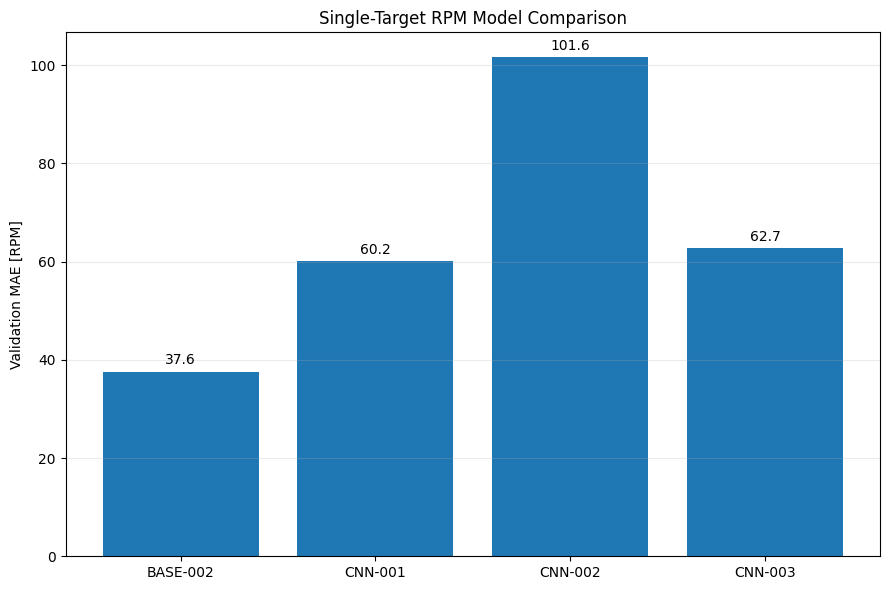

In [12]:
# Step 113 — Create final portfolio figures
# We will make four separate figures, because combining models evaluated on
# different validation populations into one ranking chart would be misleading.

# Step 113.1 — RPM-only model comparison

# ============================================================
# STEP 113.1 — RPM-ONLY VALIDATION MAE
# ============================================================

import matplotlib.pyplot as plt

FINAL_FIGURE_DIR = (
    REPO_DIR
    / "results"
    / "figures"
    / "project_closeout"
)

FINAL_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


rpm_models = master_experiment_table.loc[
    master_experiment_table[
        "experiment_id"
    ].isin(
        [
            "BASE-002",
            "CNN-001",
            "CNN-002",
            "CNN-003",
        ]
    )
].copy()


fig, ax = plt.subplots(
    figsize=(9, 6)
)


bars = ax.bar(
    rpm_models[
        "experiment_id"
    ],
    rpm_models[
        "validation_rpm_mae"
    ],
)


ax.bar_label(
    bars,
    fmt="%.1f",
    padding=3,
)


ax.set_ylabel(
    "Validation MAE [RPM]"
)

ax.set_title(
    "Single-Target RPM Model Comparison"
)

ax.grid(
    axis="y",
    alpha=0.25,
)


fig.tight_layout()


RPM_FINAL_FIGURE_PATH = (
    FINAL_FIGURE_DIR
    / "01_rpm_validation_mae_final_v001.png"
)


fig.savefig(
    RPM_FINAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

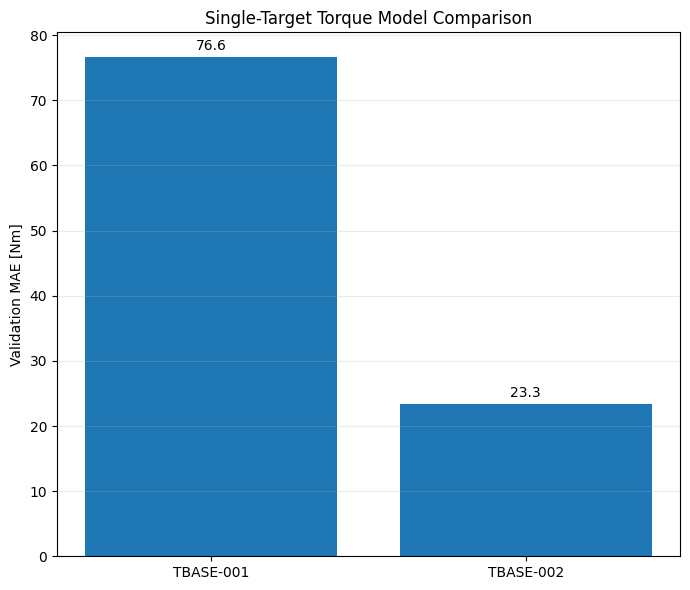

In [13]:
# Step 113.2 — Torque baseline comparison

# ============================================================
# STEP 113.2 — TORQUE BASELINE VALIDATION MAE
# ============================================================

torque_models = master_experiment_table.loc[
    master_experiment_table[
        "experiment_id"
    ].isin(
        [
            "TBASE-001",
            "TBASE-002",
        ]
    )
].copy()


fig, ax = plt.subplots(
    figsize=(7, 6)
)


bars = ax.bar(
    torque_models[
        "experiment_id"
    ],
    torque_models[
        "validation_torque_mae"
    ],
)


ax.bar_label(
    bars,
    fmt="%.1f",
    padding=3,
)


ax.set_ylabel(
    "Validation MAE [Nm]"
)

ax.set_title(
    "Single-Target Torque Model Comparison"
)

ax.grid(
    axis="y",
    alpha=0.25,
)


fig.tight_layout()


TORQUE_FINAL_FIGURE_PATH = (
    FINAL_FIGURE_DIR
    / "02_torque_validation_mae_final_v001.png"
)


fig.savefig(
    TORQUE_FINAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

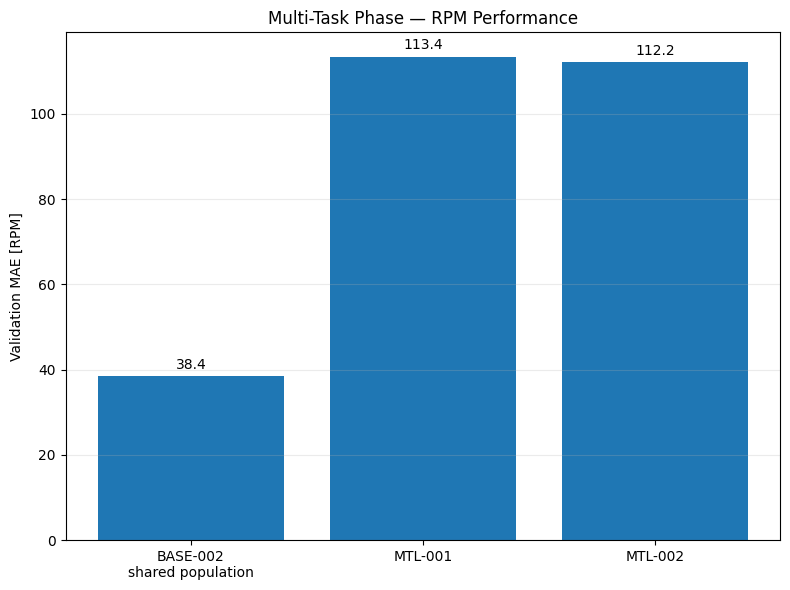

In [14]:
# Step 113.3 — Shared-population RPM comparison

# ============================================================
# STEP 113.3 — MULTI-TASK PHASE: RPM MAE
# ============================================================

rpm_shared_benchmark = float(
    mtl002_final.loc[
        mtl002_final[
            "target"
        ] == "RPM",
        "benchmark_mae",
    ].iloc[0]
)


mtl001_rpm_mae = float(
    mtl001_final.loc[
        mtl001_final[
            "target"
        ] == "RPM",
        "mtl001_mae",
    ].iloc[0]
)


mtl002_rpm_mae = float(
    mtl002_final.loc[
        mtl002_final[
            "target"
        ] == "RPM",
        "mtl002_mae",
    ].iloc[0]
)


labels = [
    "BASE-002\nshared population",
    "MTL-001",
    "MTL-002",
]

values = [
    rpm_shared_benchmark,
    mtl001_rpm_mae,
    mtl002_rpm_mae,
]


fig, ax = plt.subplots(
    figsize=(8, 6)
)


bars = ax.bar(
    labels,
    values,
)


ax.bar_label(
    bars,
    fmt="%.1f",
    padding=3,
)


ax.set_ylabel(
    "Validation MAE [RPM]"
)

ax.set_title(
    "Multi-Task Phase — RPM Performance"
)

ax.grid(
    axis="y",
    alpha=0.25,
)


fig.tight_layout()


MTL_RPM_FIGURE_PATH = (
    FINAL_FIGURE_DIR
    / "03_multitask_rpm_validation_mae_v001.png"
)


fig.savefig(
    MTL_RPM_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

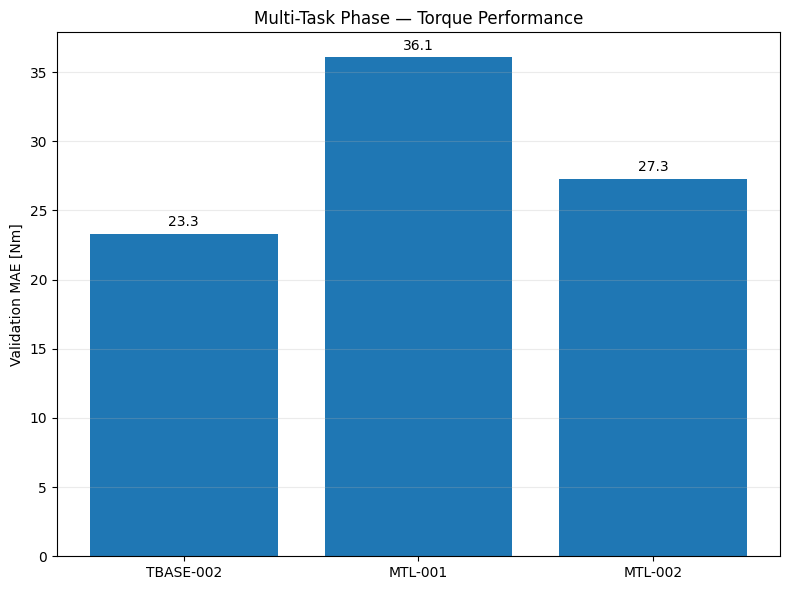

PASS: Step 113 complete.


In [15]:
# Step 113.4 — Shared-population torque comparison

# ============================================================
# STEP 113.4 — MULTI-TASK PHASE: TORQUE MAE
# ============================================================

torque_shared_benchmark = float(
    mtl002_final.loc[
        mtl002_final[
            "target"
        ] == "Torque",
        "benchmark_mae",
    ].iloc[0]
)


mtl001_torque_mae = float(
    mtl001_final.loc[
        mtl001_final[
            "target"
        ] == "Torque",
        "mtl001_mae",
    ].iloc[0]
)


mtl002_torque_mae = float(
    mtl002_final.loc[
        mtl002_final[
            "target"
        ] == "Torque",
        "mtl002_mae",
    ].iloc[0]
)


labels = [
    "TBASE-002",
    "MTL-001",
    "MTL-002",
]

values = [
    torque_shared_benchmark,
    mtl001_torque_mae,
    mtl002_torque_mae,
]


fig, ax = plt.subplots(
    figsize=(8, 6)
)


bars = ax.bar(
    labels,
    values,
)


ax.bar_label(
    bars,
    fmt="%.1f",
    padding=3,
)


ax.set_ylabel(
    "Validation MAE [Nm]"
)

ax.set_title(
    "Multi-Task Phase — Torque Performance"
)

ax.grid(
    axis="y",
    alpha=0.25,
)


fig.tight_layout()


MTL_TORQUE_FIGURE_PATH = (
    FINAL_FIGURE_DIR
    / "04_multitask_torque_validation_mae_v001.png"
)


fig.savefig(
    MTL_TORQUE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


print(
    "PASS: Step 113 complete."
)

In [16]:
# Step 114 — Write the final engineering interpretation
# This is an important portfolio artifact because it explains why the result
# matters, rather than merely listing model scores.

# Step 114.1 — Generate the interpretation report

# ============================================================
# STEP 114.1 — FINAL ENGINEERING INTERPRETATION
# ============================================================

ENGINEERING_INTERPRETATION_PATH = (
    REPO_DIR
    / "reports"
    / "engineering_interpretation_final_v001.md"
)


base002_original_mae = float(
    rpm_final.loc[
        rpm_final[
            "experiment_id"
        ] == "BASE-002",
        "mae_rpm",
    ].iloc[0]
)


cnn001_mae = float(
    rpm_final.loc[
        rpm_final[
            "experiment_id"
        ] == "CNN-001",
        "mae_rpm",
    ].iloc[0]
)


cnn003_mae = float(
    rpm_final.loc[
        rpm_final[
            "experiment_id"
        ] == "CNN-003",
        "mae_rpm",
    ].iloc[0]
)


tbase002_mae = float(
    torque_final.loc[
        torque_final[
            "experiment_id"
        ] == "TBASE-002",
        "validation_mae_nm",
    ].iloc[0]
)


report_text = f"""# Final Engineering Interpretation

## Main result

The strongest models in this project were conventional Random
Forest regressors trained on 41 engineered acoustic descriptors.

For the single-target RPM problem, BASE-002 achieved a validation
MAE of {base002_original_mae:.2f} RPM.

For torque, TBASE-002 achieved a validation MAE of
{tbase002_mae:.2f} Nm.

The tested deep-learning models did not surpass these frozen
benchmarks.

## What the CNN experiments showed

CNN-001 established that a log-mel CNN can learn a strong
relationship between acoustic content and engine RPM. Its
validation error distribution also showed reduced large-error
behavior relative to the Random Forest in some metrics.

However, the frozen primary selection metric was MAE, and CNN-001
produced {cnn001_mae:.2f} RPM MAE compared with
{base002_original_mae:.2f} RPM for BASE-002.

CNN-002 tested whether changing the regression loss would improve
this behavior. It did not produce a winning validation result.

CNN-003 explicitly preserved more absolute frequency structure in
the network, motivated by the physical relationship between RPM
and engine-order frequency. Its validation MAE was
{cnn003_mae:.2f} RPM and therefore also failed to beat BASE-002.

## What the multi-task experiments showed

MTL-001 tested whether RPM and torque could benefit from a shared
learned acoustic representation.

MTL-002 then tested a stronger hybrid hypothesis: whether the CNN
could contribute incremental information when fused with the same
engineered descriptors already used successfully by the Random
Forest models.

On the shared validation population, MTL-002 produced:

- RPM MAE: {mtl002_rpm_mae:.2f} RPM
- Torque MAE: {mtl002_torque_mae:.2f} Nm

The corresponding frozen conventional benchmarks were:

- RPM: {rpm_shared_benchmark:.2f} RPM
- Torque: {torque_shared_benchmark:.2f} Nm

MTL-002 was therefore worse on both targets and was not evaluated
on the test set.

## Engineering interpretation

The results do not imply that CNNs are generally inappropriate for
NVH prediction.

They indicate that, for this dataset and modeling formulation,
the engineered acoustic representation is already highly
informative.

The FEAT-001 descriptors explicitly summarize quantities such as
spectral shape, energy distribution, dominant frequency,
time-domain amplitude behavior and MFCC statistics. These
quantities are closely related to the stationary acoustic
signatures that change with operating state.

A Random Forest can exploit nonlinear combinations of these
features efficiently without needing to learn the entire acoustic
representation from scratch.

Several factors may also limit the observed benefit of deep
learning:

1. The dataset is synthetic and the first project uses only the
   selected A_full_set subset.

2. One-second overlapping windows increase the number of samples
   but do not provide the same statistical independence as an
   equivalent number of unrelated recordings.

3. The first models intentionally focus on steady-state operating
   conditions.

4. The test design represents unseen source WAV files within the
   same dataset subset, not unseen real engines or synthesis
   families.

5. The CNN architectures were deliberately controlled rather than
   subjected to an open-ended hyperparameter search. This protects
   validation integrity but means the study does not claim that
   every possible deep architecture would underperform.

## Final modeling decision

BASE-002 remains the selected RPM model.

TBASE-002 remains the selected torque model.

No additional CNN or multi-task tuning is justified within this
project.

The project therefore closes with a useful engineering conclusion:
model complexity should be justified by measured improvement, not
by the expectation that deep learning must outperform a carefully
constructed conventional baseline.
"""


ENGINEERING_INTERPRETATION_PATH.write_text(
    report_text,
    encoding="utf-8",
)


print(
    f"Saved:\n"
    f"{ENGINEERING_INTERPRETATION_PATH}"
)

print(
    "\nPASS: Step 114 complete."
)

Saved:
/content/engine-nvh-deep-learning/reports/engineering_interpretation_final_v001.md

PASS: Step 114 complete.


In [18]:
# Step 115 — Upgrade README into a portfolio case study
# Rather than overwrite your existing README, we'll insert a portfolio section
# between controlled markers.

# Step 115.1 — Add/update the portfolio section

# ============================================================
# STEP 115.1 — UPDATE ROOT README PORTFOLIO SECTION
# SELF-CONTAINED VERSION
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# 1. Define required persisted result files
# ------------------------------------------------------------

README_PATH = (
    REPO_DIR
    / "README.md"
)


RPM_FINAL_TABLE_PATH = (
    REPO_DIR
    / "results"
    / "tables"
    / "cnn_rpm"
    / "rpm_model_selection_final_v001.csv"
)


TORQUE_VALIDATION_TABLE_PATH = (
    REPO_DIR
    / "results"
    / "tables"
    / "torque"
    / "torque_baseline_validation_v001.csv"
)


MTL002_COMPARISON_PATH = (
    REPO_DIR
    / "results"
    / "tables"
    / "multitask"
    / "mtl002_validation_comparison_v001.csv"
)


required_paths = [
    README_PATH,
    RPM_FINAL_TABLE_PATH,
    TORQUE_VALIDATION_TABLE_PATH,
    MTL002_COMPARISON_PATH,
]


for path in required_paths:

    if not path.exists():

        raise FileNotFoundError(
            f"Required artifact missing:\n{path}"
        )


# ------------------------------------------------------------
# 2. Reload final persisted results
# ------------------------------------------------------------

rpm_final = pd.read_csv(
    RPM_FINAL_TABLE_PATH
)


torque_final = pd.read_csv(
    TORQUE_VALIDATION_TABLE_PATH
)


mtl002_final = pd.read_csv(
    MTL002_COMPARISON_PATH
)


# ------------------------------------------------------------
# 3. Recover the exact metrics needed by the README
# ------------------------------------------------------------

base002_original_mae = float(

    rpm_final.loc[
        rpm_final[
            "experiment_id"
        ] == "BASE-002",
        "mae_rpm",
    ].iloc[0]
)


tbase002_mae = float(

    torque_final.loc[
        torque_final[
            "experiment_id"
        ] == "TBASE-002",
        "validation_mae_nm",
    ].iloc[0]
)


rpm_shared_benchmark = float(

    mtl002_final.loc[
        mtl002_final[
            "target"
        ] == "RPM",
        "benchmark_mae",
    ].iloc[0]
)


mtl002_rpm_mae = float(

    mtl002_final.loc[
        mtl002_final[
            "target"
        ] == "RPM",
        "mtl002_mae",
    ].iloc[0]
)


torque_shared_benchmark = float(

    mtl002_final.loc[
        mtl002_final[
            "target"
        ] == "Torque",
        "benchmark_mae",
    ].iloc[0]
)


mtl002_torque_mae = float(

    mtl002_final.loc[
        mtl002_final[
            "target"
        ] == "Torque",
        "mtl002_mae",
    ].iloc[0]
)


print(
    "Metrics restored:"
)

print(
    f"BASE-002 RPM MAE:         "
    f"{base002_original_mae:.2f} RPM"
)

print(
    f"TBASE-002 torque MAE:     "
    f"{tbase002_mae:.2f} Nm"
)

print(
    f"Shared RPM benchmark:     "
    f"{rpm_shared_benchmark:.2f} RPM"
)

print(
    f"MTL-002 RPM MAE:          "
    f"{mtl002_rpm_mae:.2f} RPM"
)

print(
    f"Shared torque benchmark:  "
    f"{torque_shared_benchmark:.2f} Nm"
)

print(
    f"MTL-002 torque MAE:       "
    f"{mtl002_torque_mae:.2f} Nm"
)


# ------------------------------------------------------------
# 4. Read existing README
# ------------------------------------------------------------

readme_text = README_PATH.read_text(
    encoding="utf-8"
)


START_MARKER = (
    "<!-- PORTFOLIO_CASE_STUDY_START -->"
)

END_MARKER = (
    "<!-- PORTFOLIO_CASE_STUDY_END -->"
)


# ------------------------------------------------------------
# 5. Create the portfolio case-study section
# ------------------------------------------------------------

portfolio_section = f"""
{START_MARKER}

# Engine Operating-State Prediction from Acoustic Signals

## Engineering question

Can engine RPM and torque be estimated directly from engine-noise
recordings, and do learned deep representations improve upon
traditional NVH feature engineering?

## Dataset

The project uses the Procedural Engine Sounds Dataset and initially
focuses on the `A_full_set` subset.

The source WAV files contain four channels:

- left engine audio,
- right engine audio,
- scaled engine speed,
- scaled engine torque.

Raw audio is not stored in this repository.

## Modeling pipeline

The project follows a versioned engineering workflow:

`PREP-001 → SPLIT-001 → SAMPLE-MANIFEST-001 → ORDER-001 → FEAT-001`

Two acoustic representations were evaluated:

1. **FEAT-001** — 41 engineered time, spectral, band-energy and
   MFCC predictors.
2. **Log-mel spectrograms** — used as input to CNN and multi-task
   deep-learning models.

All model selection was performed using validation data.

Test data was evaluated only after a model had satisfied its frozen
validation-selection rule.

## Main results

### RPM

The selected conventional model was **BASE-002**, a Random Forest
using FEAT-001.

Validation MAE:

**{base002_original_mae:.2f} RPM**

The controlled CNN experiments did not improve upon this metric.

### Torque

The selected torque model was **TBASE-002**, also a Random Forest
using FEAT-001.

Validation MAE:

**{tbase002_mae:.2f} Nm**

### Final deep-learning experiment

MTL-002 combined:

- a frequency-aware log-mel CNN representation, and
- the same 41 engineered FEAT-001 descriptors.

On the shared validation population:

| Target | Conventional benchmark | MTL-002 |
|---|---:|---:|
| RPM MAE | {rpm_shared_benchmark:.2f} RPM | {mtl002_rpm_mae:.2f} RPM |
| Torque MAE | {torque_shared_benchmark:.2f} Nm | {mtl002_torque_mae:.2f} Nm |

MTL-002 did not satisfy the frozen validation criterion and was not
evaluated on the test split.

## Main engineering conclusion

For this synthetic dataset, sample population and one-second
steady-state formulation, carefully engineered NVH acoustic
features combined with Random Forest regression provided better
predictive accuracy than the tested end-to-end and hybrid
deep-learning architectures.

This does **not** imply that CNNs are generally inferior for NVH.
Instead, it demonstrates why strong conventional baselines,
controlled experiments and strict validation/test separation are
necessary before adding model complexity.

## Model-development sequence

FEAT-001 + Random Forest
→ strong conventional benchmark
→ CNN-001 conventional log-mel CNN
→ CNN-002 loss-function experiment
→ CNN-003 frequency-aware CNN
→ MTL-001 shared RPM + torque CNN
→ MTL-002 hybrid CNN + engineered features
→ conventional engineered-feature models remain preferred

## Final selected models

- **RPM:** BASE-002 — Random Forest + FEAT-001
- **Torque:** TBASE-002 — Random Forest + FEAT-001

Further CNN tuning was intentionally stopped after the final planned
MTL-002 experiment.

## Reproducibility

See:

`docs/reproducibility_and_architecture.md`

for the project lineage, storage strategy, experiment protocol and
reproduction workflow.

{END_MARKER}
""".strip()


# ------------------------------------------------------------
# 6. Insert or replace controlled README section
# ------------------------------------------------------------

if (
    START_MARKER in readme_text
    and
    END_MARKER in readme_text
):

    before = readme_text.split(
        START_MARKER,
        1,
    )[0]


    after = readme_text.split(
        END_MARKER,
        1,
    )[1]


    updated_readme = (

        before.rstrip()

        + "\n\n"

        + portfolio_section

        + "\n\n"

        + after.lstrip()
    )


else:

    updated_readme = (

        readme_text.rstrip()

        + "\n\n"

        + portfolio_section

        + "\n"
    )


# ------------------------------------------------------------
# 7. Save updated README
# ------------------------------------------------------------

README_PATH.write_text(
    updated_readme,
    encoding="utf-8"
)


# ------------------------------------------------------------
# 8. Verify controlled markers exist exactly once
# ------------------------------------------------------------

verification_text = README_PATH.read_text(
    encoding="utf-8"
)


assert (
    verification_text.count(
        START_MARKER
    )
    == 1
)


assert (
    verification_text.count(
        END_MARKER
    )
    == 1
)


print()
print(
    f"README updated:\n"
    f"{README_PATH}"
)

print()

print(
    "PASS: Portfolio case-study section "
    "inserted successfully."
)

Metrics restored:
BASE-002 RPM MAE:         37.62 RPM
TBASE-002 torque MAE:     23.32 Nm
Shared RPM benchmark:     38.39 RPM
MTL-002 RPM MAE:          112.16 RPM
Shared torque benchmark:  23.32 Nm
MTL-002 torque MAE:       27.30 Nm

README updated:
/content/engine-nvh-deep-learning/README.md

PASS: Portfolio case-study section inserted successfully.


In [19]:
# Step 116 — Document reproducibility and project architecture
# Step 116.1 — Create the reproducibility document
# This document explains how the project is structured, where artifacts live,
# and how another engineer could reproduce the work.

# ============================================================
# STEP 116.1 — CREATE REPRODUCIBILITY / ARCHITECTURE DOCUMENT
# ============================================================

from pathlib import Path

DOCS_DIR = (
    REPO_DIR
    / "docs"
)

DOCS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


REPRO_DOC_PATH = (
    DOCS_DIR
    / "reproducibility_and_architecture.md"
)


repro_text = """# Reproducibility and Project Architecture

## Project objective

Estimate engine RPM and torque from acoustic measurements while
comparing conventional NVH feature engineering with deep-learning
representations.

The project intentionally uses a staged model-development process
rather than assuming that the most complex model will perform best.

## Pipeline lineage

Raw 4-channel WAV files

→ Raw file manifest

→ PREP-001

→ SPLIT-001

→ SAMPLE-MANIFEST-001

→ ORDER-001

→ FEAT-001

→ Conventional RPM / torque baselines

→ Log-mel CNN models

→ Multi-task CNN models

→ Hybrid CNN + engineered-feature model

→ Frozen model-selection decisions


## Storage architecture

### GitHub repository

GitHub contains compact, reproducible project artifacts:

- notebooks
- Python source modules
- frozen YAML specifications
- split definitions
- artifact fingerprint records
- compact result tables
- selected figures
- engineering decision reports
- portfolio documentation

### Persistent external storage

Large artifacts are stored outside GitHub:

- raw WAV files
- large feature caches
- HDF5 log-mel cache
- trained model binaries
- live model-recovery checkpoints

Canonical persistent project path:

`/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState`


## Frozen preprocessing — PREP-001

PREP-001 defines:

- 1.0 second analysis windows
- 50% overlap
- 48 kHz source sampling rate
- 16 kHz model sampling rate
- mono average of the two engine-audio channels
- no per-window amplitude normalization
- primary RPM target: `rpm_mean`
- secondary torque target: `torque_mean_nm`


## Split protocol — SPLIT-001

The split is performed at the original source-WAV level.

All windows created from one parent WAV inherit the same split.

This prevents overlapping windows from the same source recording
from appearing in training, validation and test simultaneously.

Approximate split:

- 70% train
- 15% validation
- 15% test


## Model-selection protocol

### Training data

Used to:

- fit model parameters
- calculate normalization statistics
- fit feature transformations

### Validation data

Used to:

- compare model candidates
- select checkpoints
- make model-development decisions

### Test data

Used only after a model passes its frozen validation-selection rule.

Rejected CNN and multi-task models were therefore not evaluated on
the test split.


## FEAT-001 engineered acoustic representation

FEAT-001 contains 41 predictors.

### Time-domain features

- RMS
- peak absolute amplitude
- crest factor
- zero-crossing rate

### Spectral features

- spectral centroid
- spectral bandwidth
- spectral rolloff
- spectral flatness
- dominant frequency

### Band-energy features

Six frequency-band energy descriptors.

### MFCC features

- 13 MFCC means
- 13 MFCC standard deviations


## Log-mel representation

The CNN models use log-mel spectrograms generated with:

- sampling rate: 16 kHz
- FFT size: 1024
- window length: 1024
- hop length: 256
- mel bands: 64
- frequency range: 20–8000 Hz


## Model-development sequence

### RPM models

- BASE-001 — Ridge regression
- BASE-002 — Random Forest
- CNN-001 — conventional log-mel CNN
- CNN-002 — alternative CNN regression loss
- CNN-003 — frequency-aware CNN

### Torque models

- TBASE-001 — Ridge regression
- TBASE-002 — Random Forest

### Multi-task models

- MTL-001 — shared RPM + torque CNN
- MTL-002 — hybrid log-mel CNN + FEAT-001 representation


## Final selected models

### RPM

BASE-002

Random Forest using FEAT-001.

### Torque

TBASE-002

Random Forest using FEAT-001.


## Reproduction workflow

Run notebooks in numerical order.

Frozen configuration files should be treated as immutable experiment
specifications.

If an experimental specification changes, create a new version
rather than modifying a previously evaluated configuration.

Large persistent artifacts must be restored from external storage
before running notebooks that depend on them.


## Known limitations

- The dataset is synthetic.
- The first project focuses on the `A_full_set` subset.
- One-second overlapping windows are statistically correlated.
- The initial modeling phase focuses on steady-state operation.
- The test split contains unseen source WAV files within the same
  dataset subset rather than unseen real engines.
- Deep-learning experiments were deliberately controlled rather
  than subjected to an open-ended hyperparameter search.


## Engineering conclusion

For this dataset and modeling formulation, carefully engineered
acoustic descriptors combined with Random Forest regression
outperformed the tested CNN, multi-task and hybrid deep-learning
architectures.

The project therefore supports using model complexity only when it
produces measurable engineering benefit.
"""


REPRO_DOC_PATH.write_text(
    repro_text,
    encoding="utf-8",
)


print(
    f"Saved:\n{REPRO_DOC_PATH}"
)

print()

print(
    "PASS: Reproducibility document created."
)

Saved:
/content/engine-nvh-deep-learning/docs/reproducibility_and_architecture.md

PASS: Reproducibility document created.


In [20]:
# Step 117 — Clean and validate the repository
# Step 117.1 — Update .gitignore
# This protects the repository from accidentally committing large datasets,
# caches or model files.

# ============================================================
# STEP 117.1 — UPDATE .gitignore
# ============================================================

GITIGNORE_PATH = (
    REPO_DIR
    / ".gitignore"
)


if GITIGNORE_PATH.exists():

    existing_gitignore = (
        GITIGNORE_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    existing_gitignore = ""


required_ignore_entries = [

    "__pycache__/",
    "*.py[cod]",
    ".ipynb_checkpoints/",
    ".DS_Store",

    "*.wav",
    "*.h5",
    "*.hdf5",

    "*.pt",
    "*.pth",
    "*.joblib",

    "data/cached_features/",
    "models/",
]


existing_lines = (
    existing_gitignore
    .splitlines()
)


for entry in required_ignore_entries:

    if entry not in existing_lines:

        existing_lines.append(
            entry
        )


GITIGNORE_PATH.write_text(

    "\n".join(
        existing_lines
    ).rstrip()

    + "\n",

    encoding="utf-8",
)


print(
    "PASS: .gitignore updated."
)

PASS: .gitignore updated.


In [21]:
# Step 117.2 — Validate all Python source files
# This is a syntax check only.

# ============================================================
# STEP 117.2 — VALIDATE PYTHON SOURCE FILES
# ============================================================

import py_compile


SRC_DIR = (
    REPO_DIR
    / "src"
)


python_files = sorted(
    SRC_DIR.glob(
        "*.py"
    )
)


compile_failures = []


for path in python_files:

    try:

        py_compile.compile(
            str(path),
            doraise=True,
        )

        print(
            "PASS:",
            path.name,
        )

    except Exception as exc:

        compile_failures.append(
            {
                "file":
                    str(path),

                "error":
                    str(exc),
            }
        )


if compile_failures:

    print()

    print(
        "Python compilation failures:"
    )

    display(
        pd.DataFrame(
            compile_failures
        )
    )

    raise RuntimeError(
        "Python source validation failed."
    )


print()

print(
    f"PASS: All {len(python_files)} "
    f"Python source files compile."
)

PASS: __init__.py
PASS: audio_features.py
PASS: cnn_dataset.py
PASS: cnn_models.py
PASS: cnn_models_v003.py
PASS: data_loader.py
PASS: hybrid_multitask_dataset.py
PASS: hybrid_multitask_models.py
PASS: multitask_dataset.py
PASS: multitask_models.py
PASS: spectrogram_features.py

PASS: All 11 Python source files compile.


In [22]:
# Step 117.3 — Validate all YAML configuration and record files

# ============================================================
# STEP 117.3 — VALIDATE YAML FILES
# ============================================================

import yaml


yaml_files = sorted(

    list(
        (
            REPO_DIR
            / "configs"
        ).glob(
            "*.yaml"
        )
    )

    +

    list(
        (
            REPO_DIR
            / "data"
        ).glob(
            "*.yaml"
        )
    )
)


yaml_failures = []


for path in yaml_files:

    try:

        with open(
            path,
            "r",
            encoding="utf-8",
        ) as file:

            yaml.safe_load(
                file
            )


        print(
            "PASS:",
            path.relative_to(
                REPO_DIR
            ),
        )

    except Exception as exc:

        yaml_failures.append(
            {
                "file":
                    str(path),

                "error":
                    str(exc),
            }
        )


if yaml_failures:

    print()

    display(
        pd.DataFrame(
            yaml_failures
        )
    )

    raise RuntimeError(
        "One or more YAML files are invalid."
    )


print()

print(
    f"PASS: All {len(yaml_files)} YAML files parse correctly."
)

PASS: configs/cnn_rpm_v001.yaml
PASS: configs/cnn_rpm_v002.yaml
PASS: configs/cnn_rpm_v003.yaml
PASS: configs/features_v001.yaml
PASS: configs/multitask_hybrid_v001.yaml
PASS: configs/multitask_rpm_torque_v001.yaml
PASS: configs/order_analysis_v001.yaml
PASS: configs/preprocessing_v001.yaml
PASS: configs/split_v001.yaml
PASS: configs/torque_modeling_v001.yaml
PASS: data/baseline_features_v001_record.yaml
PASS: data/cnn001_checkpoint_v001_record.yaml
PASS: data/cnn001_logmel_cache_v001_record.yaml
PASS: data/cnn001_normalization_v001.yaml
PASS: data/cnn002_checkpoint_v001_record.yaml
PASS: data/cnn003_training_recovery_v001.yaml
PASS: data/dataset_record.yaml
PASS: data/mtl001_checkpoint_v001_record.yaml
PASS: data/mtl001_population_v001_record.yaml
PASS: data/mtl001_pretraining_readiness_v001.yaml
PASS: data/mtl001_target_normalization_v001.yaml
PASS: data/mtl002_checkpoint_v001_record.yaml
PASS: data/mtl002_feature_normalization_v001.yaml
PASS: data/mtl002_pretraining_readiness_v001.y

In [23]:
# Step 117.4 — Verify that large artifacts are not tracked by Git

# ============================================================
# STEP 117.4 — CHECK FOR LARGE GIT-TRACKED ARTIFACTS
# ============================================================

import subprocess


tracked_files = subprocess.run(

    [
        "git",
        "-C",
        str(REPO_DIR),
        "ls-files",
    ],

    capture_output=True,
    text=True,
    check=True,

).stdout.splitlines()


forbidden_extensions = {

    ".wav",
    ".h5",
    ".hdf5",
    ".pt",
    ".pth",
    ".joblib",
}


forbidden_tracked = [

    path

    for path in tracked_files

    if (
        Path(path)
        .suffix
        .lower()
        in forbidden_extensions
    )
]


if forbidden_tracked:

    print(
        "Large artifacts currently tracked by Git:"
    )

    for path in forbidden_tracked:

        print(
            " -",
            path,
        )

    raise RuntimeError(
        "Large generated artifacts are Git-tracked. "
        "Resolve this before final closeout."
    )


print(
    "PASS: No forbidden large artifacts are Git-tracked."
)

PASS: No forbidden large artifacts are Git-tracked.


In [24]:
# Step 117.5 — Check current repository status

# ============================================================
# STEP 117.5 — CHECK REPOSITORY STATUS
# ============================================================

git_status = subprocess.run(

    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--short",
    ],

    capture_output=True,
    text=True,
    check=True,

).stdout


print(
    "Current Git status:"
)

print(
    git_status
    if git_status.strip()
    else "Working tree currently clean."
)

Current Git status:
 M .gitignore
 M README.md
?? docs/
?? reports/engineering_interpretation_final_v001.md
?? results/figures/project_closeout/
?? results/tables/project_closeout/



Do not commit yet. We still have Step 118 artifacts to create.

In [25]:
# Step 118 — Create portfolio and project-retrospective artifacts
# Step 118.1 — Restore final metrics
# This makes the remaining closeout cells independent of variables
# created earlier in Notebook 12.

# ============================================================
# STEP 118.1 — RESTORE FINAL PROJECT METRICS
# ============================================================

RPM_FINAL_TABLE_PATH = (
    REPO_DIR
    / "results"
    / "tables"
    / "cnn_rpm"
    / "rpm_model_selection_final_v001.csv"
)


TORQUE_VALIDATION_TABLE_PATH = (
    REPO_DIR
    / "results"
    / "tables"
    / "torque"
    / "torque_baseline_validation_v001.csv"
)


MTL002_COMPARISON_PATH = (
    REPO_DIR
    / "results"
    / "tables"
    / "multitask"
    / "mtl002_validation_comparison_v001.csv"
)


rpm_final = pd.read_csv(
    RPM_FINAL_TABLE_PATH
)


torque_final = pd.read_csv(
    TORQUE_VALIDATION_TABLE_PATH
)


mtl002_final = pd.read_csv(
    MTL002_COMPARISON_PATH
)


base002_final_mae = float(

    rpm_final.loc[
        rpm_final[
            "experiment_id"
        ] == "BASE-002",
        "mae_rpm",
    ].iloc[0]
)


tbase002_final_mae = float(

    torque_final.loc[
        torque_final[
            "experiment_id"
        ] == "TBASE-002",
        "validation_mae_nm",
    ].iloc[0]
)


rpm_shared_benchmark = float(

    mtl002_final.loc[
        mtl002_final[
            "target"
        ] == "RPM",
        "benchmark_mae",
    ].iloc[0]
)


mtl002_rpm_mae = float(

    mtl002_final.loc[
        mtl002_final[
            "target"
        ] == "RPM",
        "mtl002_mae",
    ].iloc[0]
)


torque_shared_benchmark = float(

    mtl002_final.loc[
        mtl002_final[
            "target"
        ] == "Torque",
        "benchmark_mae",
    ].iloc[0]
)


mtl002_torque_mae = float(

    mtl002_final.loc[
        mtl002_final[
            "target"
        ] == "Torque",
        "mtl002_mae",
    ].iloc[0]
)


print(
    f"BASE-002 RPM MAE:        "
    f"{base002_final_mae:.2f} RPM"
)

print(
    f"TBASE-002 torque MAE:    "
    f"{tbase002_final_mae:.2f} Nm"
)

print(
    f"MTL-002 RPM MAE:         "
    f"{mtl002_rpm_mae:.2f} RPM"
)

print(
    f"MTL-002 torque MAE:      "
    f"{mtl002_torque_mae:.2f} Nm"
)

print()

print(
    "PASS: Final project metrics restored."
)

BASE-002 RPM MAE:        37.62 RPM
TBASE-002 torque MAE:    23.32 Nm
MTL-002 RPM MAE:         112.16 RPM
MTL-002 torque MAE:      27.30 Nm

PASS: Final project metrics restored.


In [26]:
# Step 118.2 — Create the portfolio summary

# ============================================================
# STEP 118.2 — CREATE PORTFOLIO SUMMARY
# ============================================================

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PORTFOLIO_SUMMARY_PATH = (
    REPORT_DIR
    / "portfolio_summary_v001.md"
)


portfolio_text = f"""# Portfolio Summary

## Project

Engine Operating-State Prediction from Acoustic Signals

## Engineering objective

Develop a machine-learning workflow capable of estimating engine RPM
and torque from engine-acoustic measurements and determine whether
deep-learning representations provide measurable benefit over
traditional NVH feature engineering.

## Technical scope

The project included:

- dataset ingestion and audit
- leakage-safe source-file splitting
- signal preprocessing
- engine-order analysis
- acoustic feature engineering
- log-mel spectrogram generation
- conventional regression
- CNN modeling
- multi-task learning
- hybrid learned + engineered feature fusion
- crash-safe training recovery
- frozen validation/test model-selection rules
- reproducible artifact and experiment management

## Final selected models

### RPM

BASE-002

Random Forest using 41 FEAT-001 engineered acoustic descriptors.

Validation MAE:

**{base002_final_mae:.2f} RPM**

### Torque

TBASE-002

Random Forest using the same FEAT-001 representation.

Validation MAE:

**{tbase002_final_mae:.2f} Nm**

## Deep-learning result

The project evaluated:

- conventional log-mel CNNs
- alternative regression loss
- frequency-aware CNN architecture
- RPM + torque multi-task learning
- hybrid CNN + engineered-feature fusion

The final hybrid model, MTL-002, achieved:

- RPM validation MAE: **{mtl002_rpm_mae:.2f} RPM**
- Torque validation MAE: **{mtl002_torque_mae:.2f} Nm**

The corresponding conventional benchmarks on the same shared
validation population were:

- RPM: **{rpm_shared_benchmark:.2f} RPM**
- Torque: **{torque_shared_benchmark:.2f} Nm**

MTL-002 therefore failed its frozen validation-selection criterion
and was not evaluated on the test split.

## Engineering conclusion

For this dataset and one-second steady-state acoustic formulation,
domain-informed acoustic descriptors combined with Random Forest
regression provided better predictive accuracy than the tested
end-to-end and hybrid deep-learning architectures.

The project demonstrates that model complexity should be justified
by measurable improvement rather than assumed to be beneficial.

## Resume-style bullets

- Developed a version-controlled NVH machine-learning pipeline for
  engine RPM and torque estimation from acoustic measurements,
  including leakage-safe source-level splitting, signal
  preprocessing, feature engineering and model evaluation.

- Implemented and compared Random Forest regression, log-mel CNNs,
  frequency-aware CNNs, multi-task neural networks and hybrid
  engineered/learned representations under a strict
  validation/test protocol.

- Demonstrated that 41 domain-informed acoustic descriptors with
  Random Forest regression outperformed the tested deep-learning
  architectures, achieving approximately
  **{base002_final_mae:.1f} RPM** validation MAE for RPM and
  **{tbase002_final_mae:.1f} Nm** for torque.

## 60-second interview explanation

I wanted to test whether engine operating state could be inferred
directly from acoustic data using deep learning.

I first created strong conventional baselines using NVH-inspired
time-domain, spectral, band-energy and MFCC features.

I then progressed through conventional CNNs, a frequency-aware CNN,
multi-task RPM and torque learning, and finally a hybrid network that
combined learned spectrogram representations with the engineered
features.

The key result was that the Random Forest baselines remained more
accurate.

Rather than continuing to tune neural networks against the
validation set until one happened to win, I stopped model
development according to predefined criteria.

That made the main engineering lesson of the project very clear:
use the simplest modeling approach that the evidence supports.
"""


PORTFOLIO_SUMMARY_PATH.write_text(
    portfolio_text,
    encoding="utf-8",
)


print(
    f"Saved:\n{PORTFOLIO_SUMMARY_PATH}"
)

print()

print(
    "PASS: Portfolio summary created."
)

Saved:
/content/engine-nvh-deep-learning/reports/portfolio_summary_v001.md

PASS: Portfolio summary created.


In [27]:
# Step 118.3 — Create the project working-style retrospective

# ============================================================
# STEP 118.3 — CREATE WORKING-STYLE RETROSPECTIVE
# ============================================================

WORKING_STYLE_PATH = (
    REPORT_DIR
    / "project_working_style_v001.md"
)


working_style_text = """# Project Working-Style Retrospective

## 1. Engineering-first model selection

The project consistently treated machine learning as an engineering
tool rather than assuming that a more complex architecture must
produce a better result.

Strong conventional baselines were created before neural-network
development began.

Model decisions remained tied to frozen quantitative criteria.


## 2. Explicit reproducible workflows

Development was most effective when each activity contained:

- a numeric step identifier
- an exact file path
- runnable code
- an expected result
- a clear stopping condition

This structure made multi-session Colab development substantially
easier to manage.


## 3. Strong artifact discipline

The project persisted:

- configurations
- manifests
- split definitions
- feature fingerprints
- model checkpoints
- normalization records
- experiment tables
- decision reports
- final figures

Large raw data and model binaries were kept outside GitHub.


## 4. Test-set discipline

Training data was used for fitting.

Validation data was used for model development and selection.

Rejected CNN and MTL candidates were not evaluated on the test set.

This prevented the test split from becoming an additional tuning
dataset.


## 5. Time-boxed development

The project was completed across multiple focused sessions.

The most reliable closeout procedure was:

1. persist generated artifacts
2. save the notebook
3. commit and synchronize GitHub
4. record the last completed step
5. define the next resume point


## 6. Controlled hypothesis testing

Later deep-learning experiments were not arbitrary architecture
changes.

Each tested a specific hypothesis:

- CNN-002: alternative regression loss
- CNN-003: preserve absolute frequency information
- MTL-001: joint RPM and torque supervision
- MTL-002: hybrid learned and engineered feature representation

When the final hypothesis failed to outperform the benchmarks, model
development stopped.


## Process improvements for future projects

### Check compute resources immediately before training

GPU availability should be confirmed immediately before any
long-running training cell.

### Persist recovery state from Epoch 1

Checkpoint, optimizer, early-stopping and training-shuffle state
should be saved after every epoch from the beginning.

### Create a master experiment registry earlier

Future projects should maintain one canonical experiment table from
the first model onward rather than consolidating it only at project
closeout.


## Preferred future workflow

Freeze specification

→ run one controlled experiment

→ persist evidence

→ make a decision

→ stop or version the next hypothesis


This project benefited more from disciplined experiment design,
artifact management and model-selection rigor than it would have
from simply testing a larger number of neural-network variants.
"""


WORKING_STYLE_PATH.write_text(
    working_style_text,
    encoding="utf-8",
)


print(
    f"Saved:\n{WORKING_STYLE_PATH}"
)

print()

print(
    "PASS: Working-style retrospective created."
)

Saved:
/content/engine-nvh-deep-learning/reports/project_working_style_v001.md

PASS: Working-style retrospective created.


In [28]:
# Step 118.4 — Create the project completion record

# ============================================================
# STEP 118.4 — CREATE PROJECT COMPLETION RECORD
# ============================================================

from datetime import (
    datetime,
    timezone,
)

import yaml


PROJECT_COMPLETION_PATH = (
    REPO_DIR
    / "data"
    / "project_completion_v001.yaml"
)


project_completion_record = {

    "project":
        (
            "Deep-Learning Prediction of Engine "
            "Operating State and Order Content "
            "from Acoustic Signals"
        ),

    "status":
        "complete",

    "model_development_status":
        "closed",

    "selected_models": {

        "rpm":
            "BASE-002",

        "torque":
            "TBASE-002",
    },

    "deep_learning_result":
        (
            "No tested CNN, multi-task CNN or hybrid "
            "CNN model surpassed the frozen conventional "
            "benchmarks."
        ),

    "final_deep_learning_experiment":
        "MTL-002",

    "mtl002_validation_status":
        "failed",

    "test_protocol": {

        "selected_conventional_models_tested":
            True,

        "rejected_deep_learning_models_tested":
            False,
    },

    "further_model_tuning_planned":
        False,

    "portfolio_packaging_complete":
        True,

    "completion_record_created_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),
}


with open(
    PROJECT_COMPLETION_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        project_completion_record,
        file,
        sort_keys=False,
    )


print(
    f"Saved:\n{PROJECT_COMPLETION_PATH}"
)

print()

print(
    "PASS: Project completion record created."
)

Saved:
/content/engine-nvh-deep-learning/data/project_completion_v001.yaml

PASS: Project completion record created.


In [29]:
# Step 119 — Final GitHub synchronization
# Before running the Git commands, save Notebook 12 directly to GitHub as:
# notebooks/12_project_closeout.ipynb
# Then continue.

# Step 119.1 — Stage the complete closeout package

# ============================================================
# STEP 119.1 — STAGE FINAL PROJECT ARTIFACTS
# ============================================================

import subprocess


paths_to_add = [

    "README.md",

    ".gitignore",

    "docs/reproducibility_and_architecture.md",

    "data/project_completion_v001.yaml",

    "reports/engineering_interpretation_final_v001.md",

    "reports/portfolio_summary_v001.md",

    "reports/project_working_style_v001.md",

    "results/tables/project_closeout",

    "results/figures/project_closeout",
]


existing_paths = [

    path

    for path in paths_to_add

    if (
        REPO_DIR
        / path
    ).exists()
]


subprocess.run(

    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        *existing_paths,
    ],

    check=True,
)


status_output = subprocess.run(

    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--short",
    ],

    capture_output=True,
    text=True,
    check=True,

).stdout


print(
    status_output
)

M  .gitignore
M  README.md
A  data/project_completion_v001.yaml
A  docs/reproducibility_and_architecture.md
A  reports/engineering_interpretation_final_v001.md
A  reports/portfolio_summary_v001.md
A  reports/project_working_style_v001.md
A  results/figures/project_closeout/01_rpm_validation_mae_final_v001.png
A  results/figures/project_closeout/02_torque_validation_mae_final_v001.png
A  results/figures/project_closeout/03_multitask_rpm_validation_mae_v001.png
A  results/figures/project_closeout/04_multitask_torque_validation_mae_v001.png
A  results/tables/project_closeout/final_artifact_audit_v001.csv
A  results/tables/project_closeout/master_experiment_results_v001.csv



In [30]:
# Step 119.2 — Commit the project closeout

# ============================================================
# STEP 119.2 — COMMIT PROJECT CLOSEOUT
# ============================================================

commit_result = subprocess.run(

    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Complete engine NVH portfolio project",
    ],

    capture_output=True,
    text=True,
)


print(
    commit_result.stdout
)


if commit_result.stderr:

    print(
        commit_result.stderr
    )


combined_output = (

    commit_result.stdout

    +

    commit_result.stderr

).lower()


if (
    commit_result.returncode != 0
    and
    "nothing to commit"
    not in combined_output
):

    raise RuntimeError(
        "Final project commit failed."
    )

[main 307200b] Complete engine NVH portfolio project
 13 files changed, 809 insertions(+)
 create mode 100644 data/project_completion_v001.yaml
 create mode 100644 docs/reproducibility_and_architecture.md
 create mode 100644 reports/engineering_interpretation_final_v001.md
 create mode 100644 reports/portfolio_summary_v001.md
 create mode 100644 reports/project_working_style_v001.md
 create mode 100644 results/figures/project_closeout/01_rpm_validation_mae_final_v001.png
 create mode 100644 results/figures/project_closeout/02_torque_validation_mae_final_v001.png
 create mode 100644 results/figures/project_closeout/03_multitask_rpm_validation_mae_v001.png
 create mode 100644 results/figures/project_closeout/04_multitask_torque_validation_mae_v001.png
 create mode 100644 results/tables/project_closeout/final_artifact_audit_v001.csv
 create mode 100644 results/tables/project_closeout/master_experiment_results_v001.csv



In [31]:
# Step 119.3 — Rebase and push

# ============================================================
# STEP 119.3 — REBASE AND PUSH FINAL PROJECT
# ============================================================

current_branch = subprocess.run(

    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],

    capture_output=True,
    text=True,
    check=True,

).stdout.strip()


pull_result = subprocess.run(

    [
        "git",
        "-C",
        str(REPO_DIR),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],

    capture_output=True,
    text=True,
)


print(
    pull_result.stdout
)


if pull_result.stderr:

    print(
        pull_result.stderr
    )


if pull_result.returncode != 0:

    raise RuntimeError(
        "git pull --rebase failed. "
        "Do not force push."
    )


subprocess.run(

    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],

    check=True,
)


print()

print(
    "PASS: Final project package pushed."
)


From https://github.com/vaibhavjiyer87/engine-nvh-deep-learning
 * branch            main       -> FETCH_HEAD
   b39cc20..3e6bb36  main       -> origin/main
Rebasing (1/1)

Successfully rebased and updated refs/heads/main.


PASS: Final project package pushed.


In [32]:
# Step 119.4 — Fetch remote state

# ============================================================
# STEP 119.4 — FETCH FINAL REMOTE STATE
# ============================================================

subprocess.run(

    [
        "git",
        "-C",
        str(REPO_DIR),
        "fetch",
        "origin",
    ],

    check=True,
)


print(
    "PASS: Final remote state fetched."
)

PASS: Final remote state fetched.


In [33]:
# Step 120 — Final project completion verification
# This creates no new modeling artifacts. It simply verifies that everything
# is present and synchronized.

# Step 120.1 — Verify final portfolio files

# ============================================================
# STEP 120.1 — VERIFY FINAL PORTFOLIO ARTIFACTS
# ============================================================

README_PATH = (
    REPO_DIR
    / "README.md"
)


MASTER_EXPERIMENT_TABLE_PATH = (
    REPO_DIR
    / "results"
    / "tables"
    / "project_closeout"
    / "master_experiment_results_v001.csv"
)


ENGINEERING_INTERPRETATION_PATH = (
    REPO_DIR
    / "reports"
    / "engineering_interpretation_final_v001.md"
)


REPRO_DOC_PATH = (
    REPO_DIR
    / "docs"
    / "reproducibility_and_architecture.md"
)


PORTFOLIO_SUMMARY_PATH = (
    REPO_DIR
    / "reports"
    / "portfolio_summary_v001.md"
)


WORKING_STYLE_PATH = (
    REPO_DIR
    / "reports"
    / "project_working_style_v001.md"
)


PROJECT_COMPLETION_PATH = (
    REPO_DIR
    / "data"
    / "project_completion_v001.yaml"
)


FINAL_FIGURE_DIR = (
    REPO_DIR
    / "results"
    / "figures"
    / "project_closeout"
)


RPM_FINAL_FIGURE_PATH = (
    FINAL_FIGURE_DIR
    / "01_rpm_validation_mae_final_v001.png"
)


TORQUE_FINAL_FIGURE_PATH = (
    FINAL_FIGURE_DIR
    / "02_torque_validation_mae_final_v001.png"
)


MTL_RPM_FIGURE_PATH = (
    FINAL_FIGURE_DIR
    / "03_multitask_rpm_validation_mae_v001.png"
)


MTL_TORQUE_FIGURE_PATH = (
    FINAL_FIGURE_DIR
    / "04_multitask_torque_validation_mae_v001.png"
)


final_required = {

    "README portfolio section":
        (
            "<!-- PORTFOLIO_CASE_STUDY_START -->"
            in README_PATH.read_text(
                encoding="utf-8"
            )
        ),

    "Master experiment table":
        MASTER_EXPERIMENT_TABLE_PATH.exists(),

    "Engineering interpretation":
        ENGINEERING_INTERPRETATION_PATH.exists(),

    "Reproducibility document":
        REPRO_DOC_PATH.exists(),

    "Portfolio summary":
        PORTFOLIO_SUMMARY_PATH.exists(),

    "Working-style retrospective":
        WORKING_STYLE_PATH.exists(),

    "Project completion record":
        PROJECT_COMPLETION_PATH.exists(),

    "RPM final figure":
        RPM_FINAL_FIGURE_PATH.exists(),

    "Torque final figure":
        TORQUE_FINAL_FIGURE_PATH.exists(),

    "MTL RPM final figure":
        MTL_RPM_FIGURE_PATH.exists(),

    "MTL torque final figure":
        MTL_TORQUE_FIGURE_PATH.exists(),
}


for name, passed in final_required.items():

    print(
        f"{name:36s}: "
        f"{'PASS' if passed else 'FAIL'}"
    )


if not all(
    final_required.values()
):

    raise RuntimeError(
        "One or more final project artifacts are missing."
    )


print()

print(
    "PASS: All required final artifacts are present."
)

README portfolio section            : PASS
Master experiment table             : PASS
Engineering interpretation          : PASS
Reproducibility document            : PASS
Portfolio summary                   : PASS
Working-style retrospective         : PASS
Project completion record           : PASS
RPM final figure                    : PASS
Torque final figure                 : PASS
MTL RPM final figure                : PASS
MTL torque final figure             : PASS

PASS: All required final artifacts are present.


In [34]:
# Step 120.2 — Verify GitHub synchronization and clean working tree

# ============================================================
# STEP 120.2 — FINAL GITHUB SYNCHRONIZATION CHECK
# ============================================================

local_head = subprocess.run(

    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        "HEAD",
    ],

    capture_output=True,
    text=True,
    check=True,

).stdout.strip()


remote_head = subprocess.run(

    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        f"origin/{current_branch}",
    ],

    capture_output=True,
    text=True,
    check=True,

).stdout.strip()


working_tree = subprocess.run(

    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--porcelain",
    ],

    capture_output=True,
    text=True,
    check=True,

).stdout.strip()


print(
    "Local HEAD :",
    local_head,
)

print(
    "Remote HEAD:",
    remote_head,
)


if local_head != remote_head:

    raise RuntimeError(
        "Local and remote Git HEAD do not match."
    )


if working_tree:

    print()

    print(
        "Working tree is not clean:"
    )

    print(
        working_tree
    )

    raise RuntimeError(
        "Resolve remaining repository changes "
        "before declaring project complete."
    )


print()

print(
    "PASS: Local and remote Git repositories match."
)

print(
    "PASS: Working tree is clean."
)

Local HEAD : ebc0a6e572ace34df22e3a3186d67412953e0106
Remote HEAD: ebc0a6e572ace34df22e3a3186d67412953e0106

PASS: Local and remote Git repositories match.
PASS: Working tree is clean.


In [35]:
# Step 120.3 — Print the final project status

# ============================================================
# STEP 120.3 — PROJECT COMPLETION SUMMARY
# ============================================================

print()
print("=" * 72)

print(
    "ENGINE OPERATING-STATE NVH PROJECT — COMPLETE"
)

print("=" * 72)

print()

print(
    "Selected RPM model:"
)

print(
    "  BASE-002 — Random Forest + FEAT-001"
)

print(
    f"  Validation MAE: "
    f"{base002_final_mae:.2f} RPM"
)

print()

print(
    "Selected torque model:"
)

print(
    "  TBASE-002 — Random Forest + FEAT-001"
)

print(
    f"  Validation MAE: "
    f"{tbase002_final_mae:.2f} Nm"
)

print()

print(
    "Final deep-learning experiment:"
)

print(
    "  MTL-002 — Hybrid CNN + FEAT-001"
)

print(
    "  Validation decision: REJECTED"
)

print()

print(
    f"  RPM MAE: "
    f"{mtl002_rpm_mae:.2f} RPM "
    f"vs {rpm_shared_benchmark:.2f} RPM benchmark"
)

print(
    f"  Torque MAE: "
    f"{mtl002_torque_mae:.2f} Nm "
    f"vs {torque_shared_benchmark:.2f} Nm benchmark"
)

print()

print(
    "Further model tuning: NO"
)

print(
    "Portfolio documentation: COMPLETE"
)

print(
    "Repository clean: YES"
)

print(
    "GitHub synchronized: YES"
)

print()

print("=" * 72)

print(
    "PROJECT COMPLETE"
)

print("=" * 72)


ENGINE OPERATING-STATE NVH PROJECT — COMPLETE

Selected RPM model:
  BASE-002 — Random Forest + FEAT-001
  Validation MAE: 37.62 RPM

Selected torque model:
  TBASE-002 — Random Forest + FEAT-001
  Validation MAE: 23.32 Nm

Final deep-learning experiment:
  MTL-002 — Hybrid CNN + FEAT-001
  Validation decision: REJECTED

  RPM MAE: 112.16 RPM vs 38.39 RPM benchmark
  Torque MAE: 27.30 Nm vs 23.32 Nm benchmark

Further model tuning: NO
Portfolio documentation: COMPLETE
Repository clean: YES
GitHub synchronized: YES

PROJECT COMPLETE
